# **EduPulse – Student Early Warning System**

Notebook ini mendokumentasikan proses end-to-end pengembangan model EduPulse, mulai dari pemahaman masalah bisnis, data wrangling, EDA, pemodelan, evaluasi, klasifikasi risiko, hingga penyediaan model dan fungsi prediksi untuk integrasi aplikasi.

**Tujuan utama:** memprediksi nilai ujian akhir siswa berdasarkan kehadiran, hasil tes internal, nilai tugas, dan kebiasaan belajar untuk membantu mengidentifikasi siswa yang berpotensi membutuhkan intervensi akademik lebih awal.

## **Informasi Dataset**

Dataset Final_Marks_Data.csv berisi 2.000 data siswa dengan 7 kolom awal yang mencakup identitas siswa, attendance, dua internal test, assignment score, daily study hours, dan final exam marks.

Target pemodelan adalah **Final Exam Marks (out of 100)**. Variabel akademik yang memiliki skala berbeda kemudian dikonversi ke skala 0–100 agar lebih seragam untuk analisis dan pemodelan.

### Sumber dan Lisensi Dataset

Dataset yang digunakan dalam proyek ini diperoleh dari Kaggle melalui dataset **Student Academic Performance Dataset** yang dibuat oleh Sonal Shinde.

**Source:** https://www.kaggle.com/datasets/sonalshinde123/student-academic-performance-dataset

**License:** CC0: Public Domain

# **1. Business Understanding**

### Business Problem

Sekolah membutuhkan pendekatan berbasis data untuk memperkirakan performa
ujian akhir siswa dan mengenali siswa yang berpotensi memiliki risiko
akademik sebelum hasil ujian akhir diperoleh.

Informasi mengenai kehadiran, hasil tes internal, nilai tugas, dan kebiasaan
belajar dapat digunakan sebagai dasar untuk membantu sekolah memahami kondisi
akademik siswa serta menentukan siswa yang membutuhkan perhatian lebih awal.

### Business Problems

1. Sekolah dapat mengalami keterlambatan dalam mengidentifikasi siswa yang
   berpotensi memiliki performa akademik rendah sebelum hasil ujian akhir
   tersedia.

2. Proses monitoring dapat menjadi kurang efisien ketika jumlah siswa cukup
   besar karena perlu memperhatikan berbagai indikator akademik secara manual.

3. Sekolah membutuhkan informasi pendukung untuk menentukan siswa yang perlu
   mendapatkan perhatian atau intervensi akademik lebih awal.

### Business Questions

1. **Bagaimana hubungan antara kehadiran, hasil tes internal, nilai tugas,
   dan kebiasaan belajar dengan nilai Final Exam siswa?**

2. **Faktor akademik dan kebiasaan belajar apa saja yang paling informatif
   untuk digunakan dalam memprediksi nilai Final Exam?**

3. **Model Machine Learning dan konfigurasi fitur seperti apa yang sesuai
   untuk mendukung EduPulse sebagai early warning system akademik?**

### Proposed Solution

EduPulse dikembangkan sebagai sistem early warning berbasis data yang
menggunakan model Machine Learning untuk memprediksi nilai **Final Exam** siswa.

Solusi yang digunakan adalah model regresi yang memprediksi nilai Final Exam
berdasarkan indikator akademik dan kebiasaan belajar yang tersedia pada
dataset. Hasil prediksi kemudian diterjemahkan menjadi kategori risiko
akademik **High Risk, Medium Risk, dan Low Risk** menggunakan threshold
operasional yang telah ditentukan.

### Business Needs

Kebutuhan bisnis yang ingin didukung oleh EduPulse meliputi:

1. Memperkirakan nilai Final Exam siswa sebelum hasil ujian akhir diperoleh.
2. Memahami indikator akademik yang berkaitan dengan performa ujian siswa.
3. Mendukung proses monitoring siswa yang membutuhkan perhatian lebih lanjut.
4. Menyediakan informasi risiko akademik yang lebih mudah dipahami untuk
   membantu proses intervensi awal.

### Data Requirements

Dataset yang digunakan adalah `Final_Marks_Data.csv` yang terdiri dari
**2.000 data siswa dengan 7 kolom**.

Variabel yang tersedia meliputi:

- `Student_ID`
- `Attendance (%)`
- `Internal Test 1 (out of 40)`
- `Internal Test 2 (out of 40)`
- `Assignment Score (out of 10)`
- `Daily Study Hours`
- `Final Exam Marks (out of 100)`

Target pemodelan adalah:

- `Final Exam Marks (out of 100)`

Untuk kebutuhan pemodelan, variabel akademik dengan skala yang berbeda
dikonversi ke skala 0–100 agar lebih seragam dalam proses analisis dan
pemodelan.

### Prediction Output

Hasil prediksi yang digunakan dalam EduPulse terdiri dari:

- **Predicted Final Exam Score**, yaitu perkiraan nilai ujian akhir siswa.
- **Risk Level**, yaitu kategori risiko akademik:
  - **High Risk:** Predicted Final Exam < 70
  - **Medium Risk:** Predicted Final Exam 70–<80
  - **Low Risk:** Predicted Final Exam ≥ 80

Output tersebut digunakan sebagai informasi pendukung untuk membantu proses
monitoring dan identifikasi siswa yang membutuhkan perhatian akademik lebih
lanjut.

# **2. Import Library**

Seluruh library yang digunakan dalam proses analisis, visualisasi, evaluasi, pemodelan, dan penyimpanan model disiapkan pada bagian ini.

In [190]:
# Library untuk analisis data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Library untuk preprocessing dan machine learning
from sklearn.model_selection import (
    train_test_split,
    cross_validate,
    KFold,
    GridSearchCV,
    learning_curve
)

# Model regresi
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)
from sklearn.tree import DecisionTreeRegressor

# Library untuk evaluasi model
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    classification_report,
    confusion_matrix
)

# Library untuk statistical testing
from scipy.stats import ttest_ind

### **Referensi Library dan Model**

#### Library

Library yang digunakan dalam proyek ini meliputi:

- **Pandas** — https://pandas.pydata.org/
- **NumPy** — https://numpy.org/
- **Matplotlib** — https://matplotlib.org/
- **Seaborn** — https://seaborn.pydata.org/
- **Scikit-learn** — https://scikit-learn.org/
- **Joblib** — https://joblib.readthedocs.io/
- **SciPy** — https://scipy.org/

Penggunaan library mengikuti lisensi dan ketentuan penggunaan yang ditetapkan
oleh masing-masing proyek.

#### Machine Learning Model

Model regresi yang digunakan dalam eksperimen meliputi:

- **Linear Regression**
- **Random Forest Regressor**
- **Gradient Boosting Regressor**
- **Decision Tree Regressor**

Model utama EduPulse yang digunakan pada tahap final adalah **Linear Regression**.

Dokumentasi model utama:

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html

Implementasi model menggunakan **Scikit-learn** dan mengikuti lisensi serta
ketentuan penggunaan library tersebut.

# **3. Data Gathering – Memuat Dataset**

In [191]:
df = pd.read_csv("Final_Marks_Data.csv")

In [192]:
print(df.columns.tolist())

['Student_ID', 'Attendance (%)', 'Internal Test 1 (out of 40)', 'Internal Test 2 (out of 40)', 'Assignment Score (out of 10)', 'Daily Study Hours', 'Final Exam Marks (out of 100)']


## **3.1 Ukuran Dataset**

In [193]:
print("Jumlah baris :", df.shape[0])
print("Jumlah kolom :", df.shape[1])

Jumlah baris : 2000
Jumlah kolom : 7


### Insight

**Evidence:**

Dataset yang digunakan terdiri dari **2.000 baris dan 7 kolom**. Variabel yang
tersedia meliputi `Student_ID`, `Attendance (%)`, `Internal Test 1`,
`Internal Test 2`, `Assignment Score`, `Daily Study Hours`, dan `Final Exam
Marks`.

**Trend Analysis:**

Dataset memiliki **6 variabel numerik** yang merepresentasikan kehadiran,
performa assessment, kebiasaan belajar, serta nilai ujian akhir. `Student_ID`
berfungsi sebagai identitas siswa, sedangkan `Final Exam Marks` digunakan
sebagai target dalam pemodelan regresi.

**Actionable Insight:**

Dengan **2.000 observasi**, dataset memiliki jumlah data yang dapat digunakan
untuk proses exploratory analysis, pembagian data training dan testing, serta
evaluasi model. Struktur variabel juga sudah mendukung analisis hubungan antara
indikator akademik dan nilai `Final Exam`.

## **3.2 Struktur dan Tipe Data**

In [194]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Student_ID                     2000 non-null   object
 1   Attendance (%)                 2000 non-null   int64 
 2   Internal Test 1 (out of 40)    2000 non-null   int64 
 3   Internal Test 2 (out of 40)    2000 non-null   int64 
 4   Assignment Score (out of 10)   2000 non-null   int64 
 5   Daily Study Hours              2000 non-null   int64 
 6   Final Exam Marks (out of 100)  2000 non-null   int64 
dtypes: int64(6), object(1)
memory usage: 109.5+ KB


### Insight

**Evidence:**

Dataset memiliki **7 kolom** dengan **2.000 observasi**. Berdasarkan hasil
`df.info()`, terdapat **1 kolom bertipe object** yaitu `Student_ID`, sedangkan
**6 kolom lainnya bertipe int64**.

**Trend Analysis:**

Kolom numerik terdiri dari `Attendance (%)`, `Internal Test 1`,
`Internal Test 2`, `Assignment Score`, `Daily Study Hours`, dan
`Final Exam Marks`. Seluruh variabel numerik memiliki **2.000 nilai non-null**,
sehingga tidak terdapat missing value pada struktur dataset awal.

`Student_ID` digunakan sebagai identitas siswa dan tidak menjadi variabel
numerik untuk pemodelan.

**Actionable Insight:**

Struktur tipe data sudah sesuai dengan kebutuhan analisis karena variabel
akademik dan target telah tersimpan dalam format numerik. Selanjutnya,
standardisasi nama kolom dilakukan pada tahap **Data Cleaning** agar lebih
konsisten dan mudah digunakan dalam proses EDA serta pemodelan.

## **3.3 Pemeriksaan Missing Value**

In [195]:
df.isnull().sum()

,0
Student_ID,0
Attendance (%),0
Internal Test 1 (out of 40),0
Internal Test 2 (out of 40),0
Assignment Score (out of 10),0
Daily Study Hours,0
Final Exam Marks (out of 100),0


### Insight

**Evidence:**

Hasil pemeriksaan menunjukkan bahwa seluruh **7 kolom memiliki 0 missing
value** pada **2.000 observasi**.

**Trend Analysis:**

Tidak terdapat data kosong pada `Student_ID`, `Attendance (%)`, `Internal Test 1`,
`Internal Test 2`, `Assignment Score`, `Daily Study Hours`, maupun
`Final Exam Marks`.

**Actionable Insight:**

Dataset tidak memerlukan proses imputasi atau penghapusan baris akibat missing
value. Seluruh **2.000 observasi** dapat dipertahankan untuk tahap analisis
dan pemodelan.

## **3.4 Pemeriksaan Duplicate**

In [196]:
print("Jumlah duplicate:", df.duplicated().sum())

Jumlah duplicate: 0


### Insight

**Evidence:**

Hasil pemeriksaan menunjukkan terdapat **0 data duplicate** pada dataset.

**Trend Analysis:**

Tidak ditemukan baris yang memiliki kombinasi nilai yang sama secara
keseluruhan. Dengan demikian, seluruh **2.000 observasi** memiliki baris yang
unik.

**Actionable Insight:**

Tidak diperlukan penghapusan data akibat duplicate. Seluruh **2.000 observasi**
dapat dipertahankan untuk melanjutkan proses Data Cleaning, EDA, dan
pemodelan.

## **3.5 Pemeriksaan Unique Values**

In [197]:
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

Student_ID: 2000 unique values
Attendance (%): 41 unique values
Internal Test 1 (out of 40): 23 unique values
Internal Test 2 (out of 40): 23 unique values
Assignment Score (out of 10): 7 unique values
Daily Study Hours: 5 unique values
Final Exam Marks (out of 100): 66 unique values


### Insight

**Evidence:**

Hasil pemeriksaan menunjukkan bahwa `Student_ID` memiliki **2.000 unique
values**. Sementara itu, `Attendance (%)` memiliki **41 unique values**,
`Internal Test 1` dan `Internal Test 2` masing-masing memiliki **23 unique
values**, `Assignment Score` memiliki **7 unique values**, `Daily Study Hours`
memiliki **5 unique values**, dan `Final Exam Marks` memiliki **66 unique
values**.

**Trend Analysis:**

Jumlah unique values berbeda pada setiap variabel. `Student_ID` memiliki nilai
unik untuk setiap siswa, sedangkan variabel akademik memiliki jumlah variasi
yang lebih terbatas. `Final Exam Marks` memiliki **66 nilai unik**, menunjukkan
variasi nilai yang relatif lebih besar dibandingkan `Assignment Score` yang
hanya memiliki **7 nilai unik** dan `Daily Study Hours` yang memiliki **5 nilai
unik**.

**Actionable Insight:**

Variasi nilai yang tersedia dapat digunakan untuk analisis lebih lanjut pada
tahap EDA. `Student_ID` diperlakukan sebagai identitas siswa, sedangkan
variabel akademik digunakan untuk menganalisis pola dan membangun model
prediksi `Final Exam`.

## **3.6 Pemeriksaan Rentang dan Statistik Dasar**

In [198]:
# Validasi rentang nilai setiap variabel

valid_ranges = {
    "Attendance (%)": (0, 100),
    "Internal Test 1 (out of 40)": (0, 40),
    "Internal Test 2 (out of 40)": (0, 40),
    "Assignment Score (out of 10)": (0, 10),
    "Daily Study Hours": (0, None),
    "Final Exam Marks (out of 100)": (0, 100)
}

for col, (min_valid, max_valid) in valid_ranges.items():
    min_actual = df[col].min()
    max_actual = df[col].max()

    min_check = min_actual >= min_valid
    max_check = True if max_valid is None else max_actual <= max_valid

    print(
        f"{col}: "
        f"min={min_actual}, max={max_actual} → "
        f"{'Valid' if min_check and max_check else 'Invalid'}"
    )

Attendance (%): min=52, max=100 → Valid
Internal Test 1 (out of 40): min=18, max=40 → Valid
Internal Test 2 (out of 40): min=16, max=40 → Valid
Assignment Score (out of 10): min=4, max=10 → Valid
Daily Study Hours: min=1, max=5 → Valid
Final Exam Marks (out of 100): min=25, max=100 → Valid


### Insight

**Evidence:**

Hasil validasi menunjukkan bahwa seluruh variabel berada dalam rentang yang
valid. `Attendance (%)` memiliki rentang **52–100**, `Internal Test 1`
**18–40**, `Internal Test 2` **16–40**, `Assignment Score` **4–10**,
`Daily Study Hours` **1–5**, dan `Final Exam Marks` **25–100**.

Rata-rata `Attendance` adalah **84,89**, sedangkan rata-rata `Final Exam Marks`
adalah **64,86**.

**Trend Analysis:**

Tidak ditemukan nilai yang berada di luar rentang valid yang telah ditentukan.
Hal ini menunjukkan bahwa nilai numerik dalam dataset berada pada batas yang
sesuai dengan karakteristik masing-masing variabel.

**Actionable Insight:**

Tidak diperlukan koreksi nilai berdasarkan pemeriksaan rentang pada tahap
**Data Cleaning**. Dataset dapat dilanjutkan ke tahap EDA dengan mempertahankan
seluruh **2.000 observasi**.

In [199]:
numeric_columns = df.select_dtypes(include=np.number).columns

for col in numeric_columns:
    print(f"\n--- {col} ---")
    print("Min :", df[col].min())
    print("Max :", df[col].max())
    print("Mean:", round(df[col].mean(), 2))


--- Attendance (%) ---
Min : 52
Max : 100
Mean: 84.89

--- Internal Test 1 (out of 40) ---
Min : 18
Max : 40
Mean: 32.12

--- Internal Test 2 (out of 40) ---
Min : 16
Max : 40
Mean: 32.46

--- Assignment Score (out of 10) ---
Min : 4
Max : 10
Mean: 7.51

--- Daily Study Hours ---
Min : 1
Max : 5
Mean: 2.82

--- Final Exam Marks (out of 100) ---
Min : 25
Max : 100
Mean: 64.86


## **3.7 Statistik Deskriptif Final Exam**

In [200]:
df['Final Exam Marks (out of 100)'].describe()

,Final Exam Marks (out of 100)
count,2000.000000
mean,64.855000
std,11.341265
min,25.000000
25%,58.000000
50%,65.000000
75%,73.000000
max,100.000000


### Insight

**Evidence:**

Berdasarkan statistik deskriptif, terdapat **2.000 data siswa** dengan rata-rata
nilai `Final Exam` sebesar **64,86** dan standar deviasi sebesar **11,34**.
Nilai minimum adalah **25**, Q1 sebesar **58**, median **65**, Q3 sebesar
**73**, dan nilai maksimum **100**.

**Trend Analysis:**

Sebanyak 50% data siswa memiliki nilai `Final Exam` pada rentang **58–73**.
Sementara itu, keseluruhan data memiliki rentang nilai **25–100**, yang
menunjukkan adanya variasi performa antar siswa.

**Actionable Insight:**

Distribusi statistik `Final Exam` memberikan gambaran awal mengenai variasi
performa siswa dan menjadi dasar untuk analisis distribusi frekuensi serta
profil performa pada tahap berikutnya.

## **3.8 Distribusi Frekuensi Nilai Final Exam**

In [201]:
df['Final Exam Marks (out of 100)'].value_counts().sort_index()

,count
Final Exam Marks (out of 100),
25,1
26,1
31,1
32,1
34,1
...,...
91,3
92,2
93,3


### Insight

**Evidence:**

Distribusi frekuensi menunjukkan bahwa `Final Exam` memiliki **66 nilai unik**
dalam rentang **25–100**. Beberapa nilai seperti **25, 26, 31, 32, dan 34**
masing-masing muncul **1 kali**, sedangkan nilai pada rentang tinggi seperti
**91–94** juga memiliki frekuensi yang relatif rendah.

**Trend Analysis:**

Nilai `Final Exam` tersebar pada rentang yang cukup luas dan tidak hanya
terkonsentrasi pada beberapa nilai tertentu. Hal ini menunjukkan adanya variasi
performa siswa dalam dataset.

**Actionable Insight:**

Variasi distribusi `Final Exam` dapat digunakan sebagai dasar untuk memahami
karakteristik performa siswa sebelum dilakukan analisis hubungan dengan
indikator akademik lainnya.

# **4. Data Cleaning**

## **4.1 Standardisasi Nama Kolom**

In [202]:
# Standardisasi nama kolom

df = df.rename(columns={
    'Student_ID': 'student_id',
    'Attendance (%)': 'attendance',
    'Internal Test 1 (out of 40)': 'internal_test_1',
    'Internal Test 2 (out of 40)': 'internal_test_2',
    'Assignment Score (out of 10)': 'assignment_score',
    'Daily Study Hours': 'daily_study_hours',
    'Final Exam Marks (out of 100)': 'final_exam'
})

df.head()

,student_id,attendance,internal_test_1,internal_test_2,assignment_score,daily_study_hours,final_exam
0,S1000,84,30,36,7,3,72
1,S1001,91,24,38,6,3,56
2,S1002,73,29,26,7,3,56
3,S1003,80,36,35,7,3,74
4,S1004,84,31,37,8,3,66


### Insight

**Evidence:**

Standardisasi mengubah nama kolom menjadi format yang lebih konsisten, yaitu
`student_id`, `attendance`, `internal_test_1`, `internal_test_2`,
`assignment_score`, `daily_study_hours`, dan `final_exam`.

**Trend Analysis:**

Perubahan dilakukan hanya pada nama kolom sehingga tidak mengubah **2.000
baris dan 7 kolom** maupun nilai yang terdapat dalam dataset.

**Actionable Insight:**

Nama kolom yang telah distandardisasi memudahkan proses pemanggilan variabel,
feature engineering, analisis EDA, dan pemodelan pada tahap berikutnya.

## **4.2 Validasi Tipe Data**

In [203]:
# Validasi tipe data numerik

numeric_columns = [
    "attendance",
    "internal_test_1",
    "internal_test_2",
    "assignment_score",
    "daily_study_hours",
    "final_exam"
]

for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors="raise")

print("Tipe data setelah validasi:")
print(df.dtypes)

Tipe data setelah validasi:
student_id           object
attendance            int64
internal_test_1       int64
internal_test_2       int64
assignment_score      int64
daily_study_hours     int64
final_exam            int64
dtype: object


### Insight

**Evidence:**

Hasil validasi menunjukkan bahwa `student_id` bertipe **object**, sedangkan
`attendance`, `internal_test_1`, `internal_test_2`, `assignment_score`,
`daily_study_hours`, dan `final_exam` masing-masing bertipe **int64**.

**Trend Analysis:**

Seluruh **6 variabel numerik** telah memiliki tipe data numerik yang sesuai,
sehingga dapat digunakan untuk operasi statistik, feature engineering, dan
pemodelan.

**Actionable Insight:**

Tidak diperlukan konversi tipe data tambahan. Dataset dapat dilanjutkan ke tahap
pemeriksaan duplicate dan outlier dengan struktur tipe data yang telah
tervalidasi.

## **4.3 Pemeriksaan Data Duplikat**

In [204]:
# Memastikan tidak ada perubahan jumlah data
# Memastikan missing value dan duplicate tetap aman

print("Jumlah baris :", df.shape[0])
print("Jumlah kolom :", df.shape[1])
print("Total missing value :", df.isnull().sum().sum())
print("Total duplicate     :", df.duplicated().sum())

Jumlah baris : 2000
Jumlah kolom : 7
Total missing value : 0
Total duplicate     : 0


### Insight

**Evidence:**

Hasil pemeriksaan menunjukkan **0 data duplicate** dan **0 missing value** pada
dataset yang terdiri dari **2.000 baris dan 7 kolom**.

**Trend Analysis:**

Tidak ditemukan baris yang terduplikasi secara keseluruhan, sehingga tidak ada
observasi yang perlu dihapus akibat duplicate.

**Actionable Insight:**

Seluruh **2.000 observasi** dapat dipertahankan untuk tahap berikutnya tanpa
kehilangan data akibat proses deduplikasi.

## **4.4 Pemeriksaan Outlier**

Pemeriksaan outlier dilakukan menggunakan metode Interquartile Range (IQR)
untuk mengidentifikasi nilai yang secara statistik berada di luar batas
1,5 × IQR.

Nilai yang terdeteksi sebagai outlier tidak langsung dihapus. Setiap nilai
tetap dipertahankan selama masih berada dalam rentang yang masuk akal secara
konteks akademik.

In [205]:
# Pemeriksaan outlier menggunakan metode Interquartile Range (IQR)

outlier_columns = [
    "attendance",
    "internal_test_1",
    "internal_test_2",
    "assignment_score",
    "daily_study_hours",
    "final_exam"
]

outlier_summary = []

for column in outlier_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = (
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ).sum()

    outlier_summary.append({
        "column": column,
        "Q1": Q1,
        "Q3": Q3,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": outlier_count
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary

,column,Q1,Q3,lower_bound,upper_bound,outlier_count
0,attendance,80.0,90.0,65.0,105.0,10
1,internal_test_1,29.0,35.0,20.0,44.0,8
2,internal_test_2,29.0,36.0,18.5,46.5,1
3,assignment_score,7.0,8.0,5.5,9.5,79
4,daily_study_hours,2.0,3.0,0.5,4.5,3
5,final_exam,58.0,73.0,35.5,95.5,7


### Insight

**Evidence:**

Pemeriksaan menggunakan metode Interquartile Range (IQR) mendeteksi outlier
statistik pada beberapa variabel. Jumlah outlier adalah **10 data** pada
`attendance`, **8 data** pada `internal_test_1`, **1 data** pada
`internal_test_2`, **79 data** pada `assignment_score`, **3 data** pada
`daily_study_hours`, dan **7 data** pada `final_exam`.

**Trend Analysis:**

Outlier terbanyak ditemukan pada `assignment_score` dengan **79 data**.
Meskipun terdeteksi secara statistik, nilai-nilai tersebut masih berada dalam
rentang yang valid secara akademik, seperti `assignment_score` **4–10** dan
`final_exam` **25–100**.

**Actionable Insight:**

Outlier tidak dihapus karena tidak ditemukan indikasi bahwa nilai tersebut
merupakan kesalahan input. Seluruh data dipertahankan agar informasi akademik
yang tersedia tetap lengkap untuk proses analisis dan pemodelan.

## **4.5 Verifikasi Setelah Cleaning**

Tahap verifikasi dilakukan untuk memastikan kondisi dataset setelah proses
cleaning tetap konsisten dengan hasil assessment sebelumnya.

Pemeriksaan meliputi jumlah baris dan kolom, missing value, duplicate, serta
struktur kolom yang digunakan untuk proses analisis dan pemodelan.

In [206]:
# Verifikasi setelah cleaning

print("Jumlah baris :", df.shape[0])
print("Jumlah kolom :", df.shape[1])
print("Total missing value :", df.isnull().sum().sum())
print("Total duplicate :", df.duplicated().sum())
print("Kolom dataset :", df.columns.tolist())

Jumlah baris : 2000
Jumlah kolom : 7
Total missing value : 0
Total duplicate : 0
Kolom dataset : ['student_id', 'attendance', 'internal_test_1', 'internal_test_2', 'assignment_score', 'daily_study_hours', 'final_exam']


### Insight

**Evidence:**

Hasil verifikasi setelah cleaning menunjukkan bahwa dataset tetap memiliki
**2.000 baris dan 7 kolom**, dengan **0 missing value** dan **0 duplicate**.
Struktur kolom telah distandardisasi menjadi:

`student_id`, `attendance`, `internal_test_1`, `internal_test_2`,
`assignment_score`, `daily_study_hours`, dan `final_exam`.

**Trend Analysis:**

Proses cleaning tidak mengurangi jumlah observasi dan tidak menghasilkan
perubahan yang tidak diharapkan pada struktur dataset.

**Actionable Insight:**

Dataset hasil cleaning dinyatakan siap digunakan untuk tahap
**Exploratory Data Analysis (EDA)** dan pemodelan tanpa perlu penghapusan atau
imputasi tambahan.

# **5. Exploratory Data Analysis (EDA)**

## Exploratory Data Analysis (EDA)

Tahap Exploratory Data Analysis (EDA) dilakukan untuk memahami
karakteristik data dan menemukan pola hubungan antara faktor akademik
siswa dengan nilai ujian akhir.

Analisis difokuskan pada variabel attendance, internal test,
assignment score, daily study hours, dan final exam sebagai target.


## **5.1 Statistik Deskriptif**

In [207]:
# Statistik deskriptif seluruh variabel numerik

df.describe()

,attendance,internal_test_1,internal_test_2,assignment_score,daily_study_hours,final_exam
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,84.891500,32.115500,32.464500,7.507000,2.823500,64.855000
std,7.758855,4.563504,4.522827,1.021015,0.608714,11.341265
min,52.000000,18.000000,16.000000,4.000000,1.000000,25.000000
25%,80.000000,29.000000,29.000000,7.000000,2.000000,58.000000
50%,85.000000,32.000000,33.000000,8.000000,3.000000,65.000000
75%,90.000000,35.000000,36.000000,8.000000,3.000000,73.000000
max,100.000000,40.000000,40.000000,10.000000,5.000000,100.000000


### Insight

**Evidence:**

Dataset memiliki **2.000 observasi** pada seluruh variabel numerik. Rata-rata
`attendance` adalah **84,89%**, `internal_test_1` sebesar **32,12**,
`internal_test_2` sebesar **32,46**, `assignment_score` sebesar **7,51**, dan
`daily_study_hours` sebesar **2,82 jam per hari**.

Untuk target pemodelan, `final_exam` memiliki rata-rata **64,86**, median
**65**, standar deviasi **11,34**, serta rentang nilai **25–100**.

**Trend Analysis:**

Nilai tengah `final_exam` berada pada **65**, sementara 50% data berada pada
rentang **58–73** berdasarkan kuartil pertama dan ketiga. Variasi nilai juga
terlihat dari rentang masing-masing indikator akademik, seperti `attendance`
**52–100**, `internal_test_1` **18–40**, dan `internal_test_2` **16–40**.

**Actionable Insight:**

Statistik deskriptif menunjukkan adanya variasi performa akademik antar siswa
yang dapat digunakan untuk tahap EDA berikutnya. Distribusi dan hubungan
antara indikator akademik dengan `final_exam` kemudian dianalisis untuk
mengidentifikasi variabel yang informatif bagi pemodelan.

## **5.2 Distribusi Variabel Akademik**

Analisis distribusi digunakan untuk melihat pola nilai dan karakteristik
masing-masing variabel akademik pada seluruh siswa.

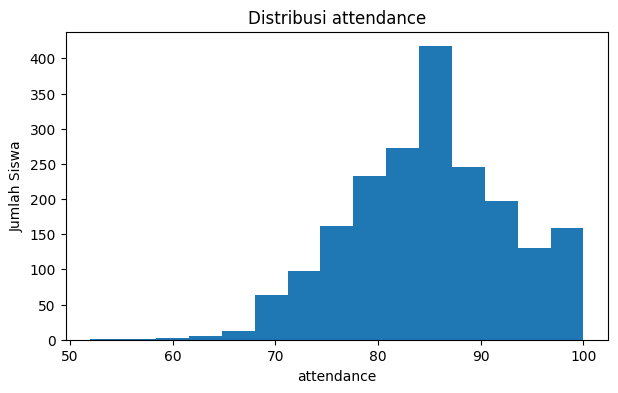

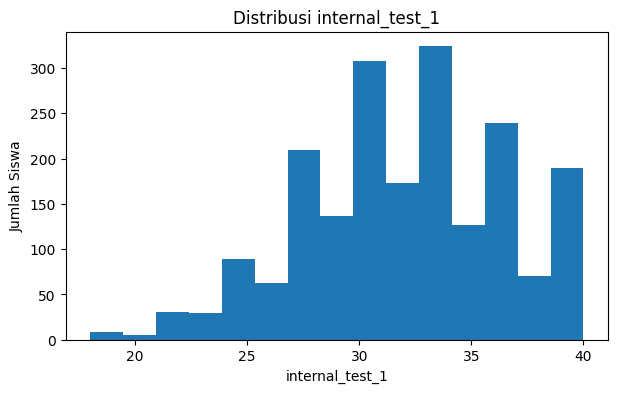

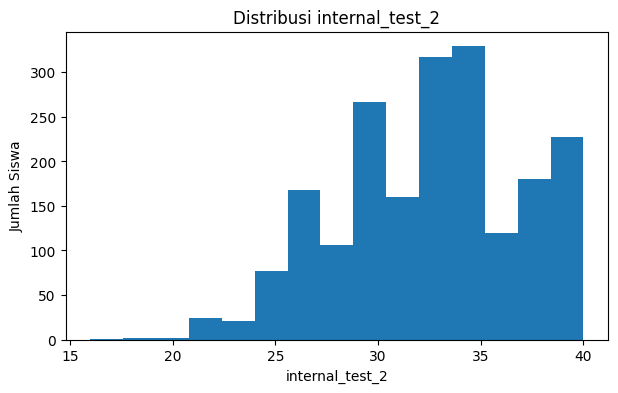

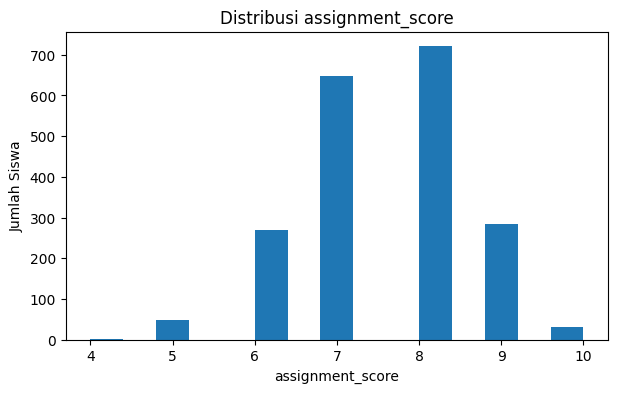

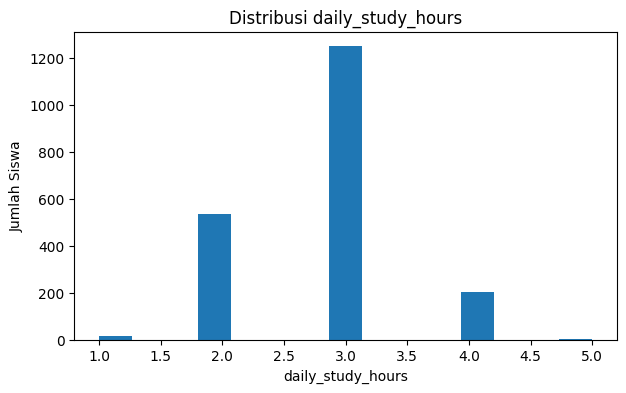

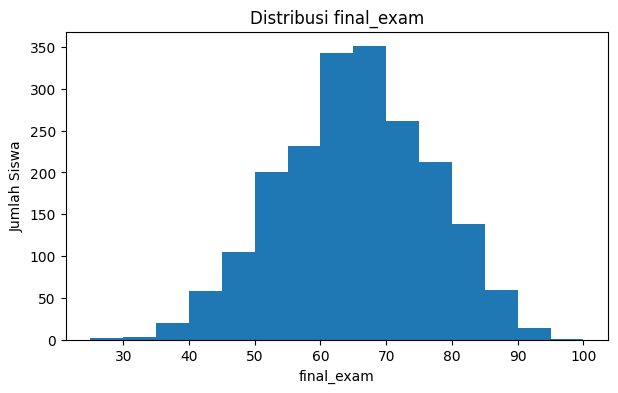

In [208]:
features = [
    'attendance',
    'internal_test_1',
    'internal_test_2',
    'assignment_score',
    'daily_study_hours',
    'final_exam'
]

for feature in features:
    plt.figure(figsize=(7, 4))
    plt.hist(df[feature], bins=15)
    plt.title(f'Distribusi {feature}')
    plt.xlabel(feature)
    plt.ylabel('Jumlah Siswa')
    plt.show()

### Insight

**Evidence:**

Histogram menunjukkan bahwa `attendance` berada pada rentang **52–100%**,
`internal_test_1` pada **18–40**, `internal_test_2` pada **16–40**,
`assignment_score` pada **4–10**, `daily_study_hours` pada **1–5 jam**, dan
`final_exam` pada **25–100**.

Nilai median `attendance` adalah **85%**, median `internal_test_1` **32**,
median `internal_test_2` **33**, median `assignment_score` **8**,
median `daily_study_hours` **3 jam**, dan median `final_exam` **65**.

**Trend Analysis:**

Distribusi menunjukkan bahwa sebagian besar nilai indikator akademik berada
pada rentang menengah hingga tinggi. `Assignment Score` dan
`Daily Study Hours` memiliki variasi nilai yang lebih terbatas dibandingkan
`Attendance` dan `Final Exam`.

**Actionable Insight:**

Distribusi setiap variabel memberikan gambaran awal mengenai variasi performa
siswa. Hasil ini digunakan sebagai dasar untuk melanjutkan analisis hubungan
antarvariabel melalui korelasi dan scatter plot.

## **5.3 Hubungan Variabel Akademik dengan Final Exam**

Analisis korelasi dilakukan untuk mengidentifikasi hubungan antara
faktor akademik siswa dengan nilai ujian akhir. Hasil ini digunakan
sebagai dasar untuk memahami variabel yang berpotensi informatif
dalam pembangunan model prediksi.

In [209]:
correlation = df.select_dtypes(include=np.number).corr()

correlation['final_exam'].sort_values(ascending=False)

,final_exam
final_exam,1.000000
attendance,0.725644
internal_test_2,0.691049
internal_test_1,0.689227
assignment_score,0.669400
daily_study_hours,0.412877


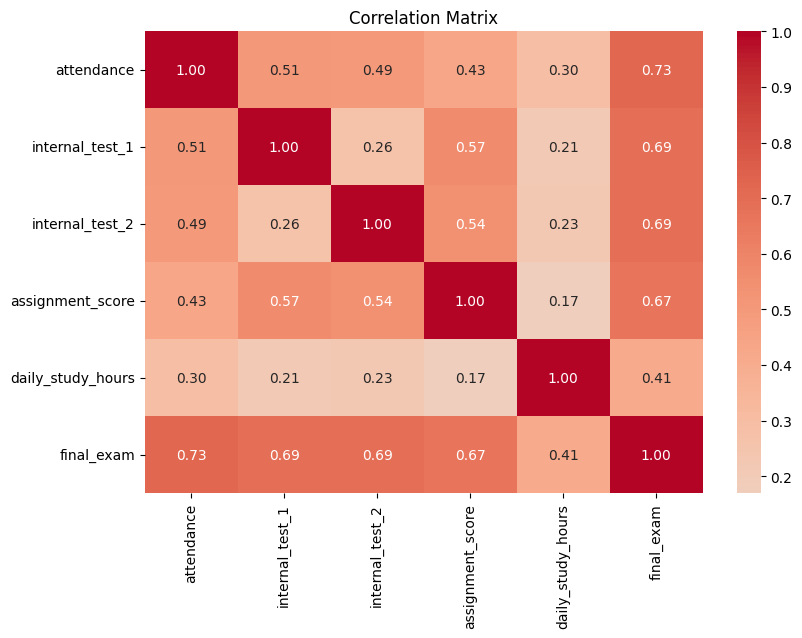

In [210]:
plt.figure(figsize=(9, 6))

sns.heatmap(
    correlation,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Matrix')
plt.show()

### Insight

**Evidence:**

Hasil korelasi menunjukkan hubungan positif antara seluruh indikator akademik
dengan `final_exam`. Korelasi masing-masing variabel adalah `attendance`
**0,7256**, `internal_test_1` **0,6892**, `internal_test_2` **0,6910**,
`assignment_score` **0,6694**, dan `daily_study_hours` **0,4129**.

**Trend Analysis:**

`Attendance` memiliki korelasi paling tinggi di antara indikator individual
dengan nilai `final_exam`, yaitu **0,7256**. Sementara itu,
`daily_study_hours` memiliki korelasi paling rendah sebesar **0,4129**.
Seluruh koefisien bernilai positif, sehingga nilai indikator yang lebih tinggi
secara umum berkaitan dengan nilai `final_exam` yang lebih tinggi.

**Actionable Insight:**

Indikator akademik yang memiliki hubungan positif dengan `final_exam` dapat
digunakan sebagai kandidat fitur dalam model prediksi. Hasil korelasi bersifat
observasional dan tidak digunakan untuk menyimpulkan hubungan sebab-akibat.

## **5.4 Scatter Plot Faktor Akademik dengan Final Exam**

Untuk memahami lebih lanjut hubungan antara setiap indikator akademik
dengan nilai ujian akhir, digunakan scatter plot. Analisis ini membantu
mengidentifikasi pola hubungan dan variasi nilai Final Exam pada
tingkat indikator akademik yang berbeda.

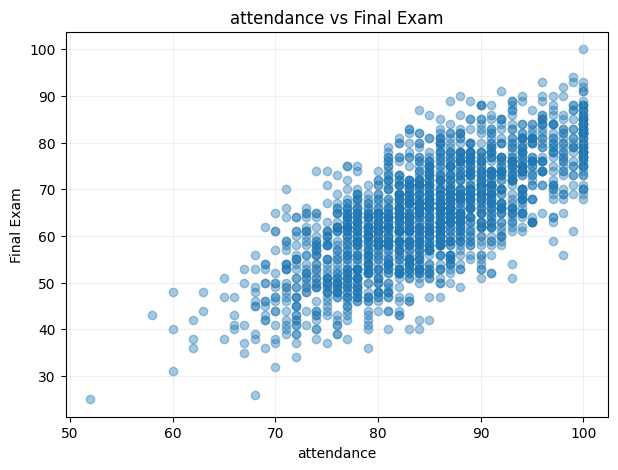

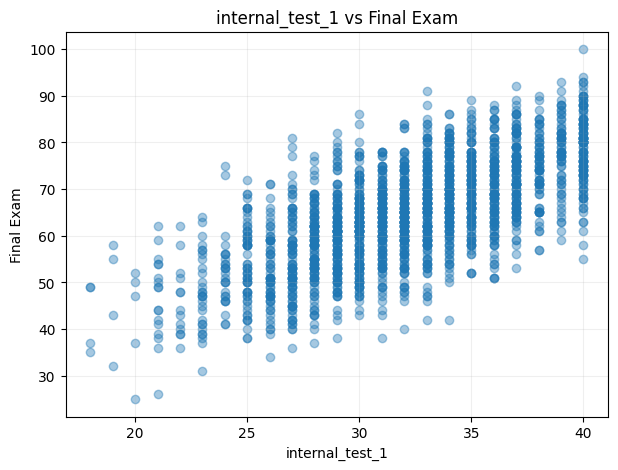

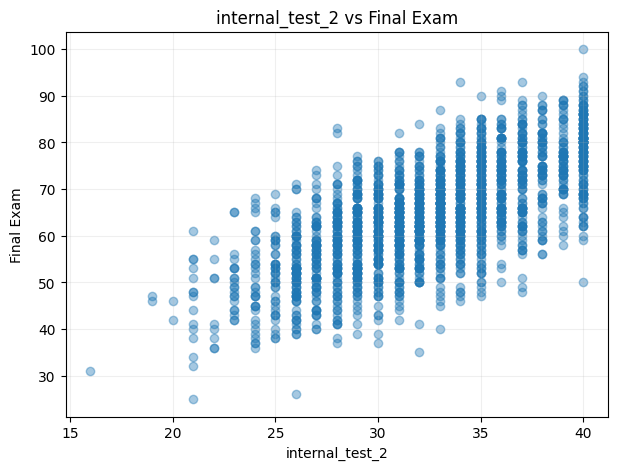

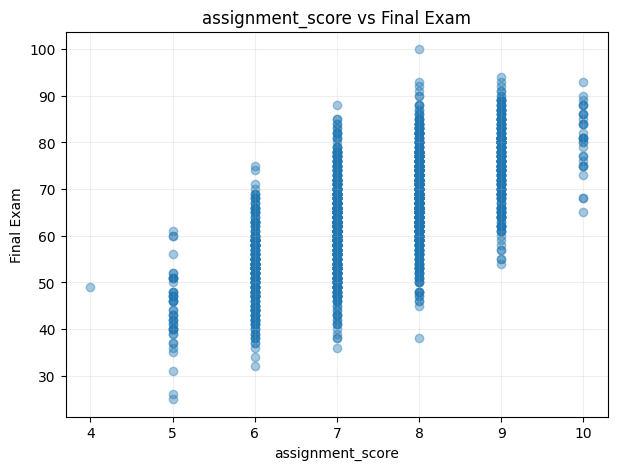

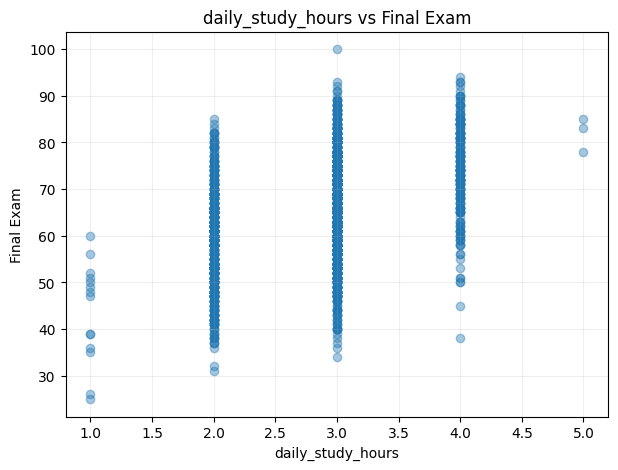

In [211]:
features = [
    'attendance',
    'internal_test_1',
    'internal_test_2',
    'assignment_score',
    'daily_study_hours'
]

for feature in features:
    plt.figure(figsize=(7, 5))

    plt.scatter(
        df[feature],
        df['final_exam'],
        alpha=0.4
    )

    plt.title(f'{feature} vs Final Exam')
    plt.xlabel(feature)
    plt.ylabel('Final Exam')
    plt.grid(alpha=0.2)
    plt.show()

### Insight

**Evidence:**

Scatter plot menunjukkan pola hubungan positif antara setiap indikator
akademik dengan `final_exam`. Korelasi `attendance` dengan `final_exam`
sebesar **0,7256**, `internal_test_2` **0,6910**, `internal_test_1`
**0,6892**, `assignment_score` **0,6694**, dan `daily_study_hours`
**0,4129**.

**Trend Analysis:**

Pola titik pada scatter plot secara umum mengikuti kecenderungan meningkat,
yaitu siswa dengan nilai indikator akademik yang lebih tinggi cenderung
memiliki `final_exam` yang lebih tinggi. `Attendance` menunjukkan hubungan
linear paling kuat di antara variabel individual berdasarkan nilai korelasi.

**Actionable Insight:**

Scatter plot memperkuat hasil correlation analysis dan memberikan visualisasi
hubungan antara indikator akademik dengan `final_exam`. Hasil ini dapat
digunakan sebagai dasar eksplorasi fitur untuk model prediksi, tanpa
menginterpretasikannya sebagai hubungan sebab-akibat.

## **5.5 Rescaling Nilai Akademik**

In [212]:
# Konversi nilai akademik ke skala 0-100

df['internal_test_1_pct'] = df['internal_test_1'] / 40 * 100
df['internal_test_2_pct'] = df['internal_test_2'] / 40 * 100
df['assignment_pct'] = df['assignment_score'] / 10 * 100

df[
    [
        'internal_test_1',
        'internal_test_1_pct',
        'internal_test_2',
        'internal_test_2_pct',
        'assignment_score',
        'assignment_pct'
    ]
].head()

,internal_test_1,internal_test_1_pct,internal_test_2,internal_test_2_pct,assignment_score,assignment_pct
0,30,75.0,36,90.0,7,70.0
1,24,60.0,38,95.0,6,60.0
2,29,72.5,26,65.0,7,70.0
3,36,90.0,35,87.5,7,70.0
4,31,77.5,37,92.5,8,80.0


In [213]:
# Membandingkan korelasi sebelum dan sesudah rescaling

original_corr = df[
    [
        'attendance',
        'internal_test_1',
        'internal_test_2',
        'assignment_score',
        'final_exam'
    ]
].corr()['final_exam']

scaled_corr = df[
    [
        'attendance',
        'internal_test_1_pct',
        'internal_test_2_pct',
        'assignment_pct',
        'final_exam'
    ]
].corr()['final_exam']

comparison = pd.DataFrame({
    'Before Scaling': [
        original_corr['attendance'],
        original_corr['internal_test_1'],
        original_corr['internal_test_2'],
        original_corr['assignment_score']
    ],
    'After Scaling': [
        scaled_corr['attendance'],
        scaled_corr['internal_test_1_pct'],
        scaled_corr['internal_test_2_pct'],
        scaled_corr['assignment_pct']
    ]
}, index=[
    'Attendance',
    'Internal Test 1',
    'Internal Test 2',
    'Assignment'
])

comparison

,Before Scaling,After Scaling
Attendance,0.725644,0.725644
Internal Test 1,0.689227,0.689227
Internal Test 2,0.691049,0.691049
Assignment,0.669400,0.669400


### Insight

**Evidence:**

`internal_test_1`, `internal_test_2`, dan `assignment_score` dikonversi ke
skala **0–100** melalui `internal_test_1_pct`, `internal_test_2_pct`, dan
`assignment_pct`.

Hasil perbandingan menunjukkan bahwa korelasi terhadap `final_exam` tetap
sama sebelum dan sesudah rescaling, yaitu `attendance` **0,7256**,
`internal_test_1` **0,6892**, `internal_test_2` **0,6910**, dan
`assignment_score` **0,6694**.

**Trend Analysis:**

Rescaling mengubah skala numerik tanpa mengubah nilai hubungan linear dengan
`final_exam`. Dengan demikian, transformasi ke skala 0–100 tidak mengubah
pola hubungan yang telah ditemukan pada tahap EDA.

**Actionable Insight:**

Fitur hasil rescaling dapat digunakan untuk menyamakan skala variabel
assessment sebelum feature engineering dan pemodelan. Transformasi ini
memudahkan interpretasi nilai akademik dalam satu skala **0–100** tanpa
mengubah hubungan korelasionalnya.

## **5.6 Profil Siswa Berdasarkan Performa Akademik**

Untuk memahami karakteristik siswa berdasarkan performa akademik,
siswa dikelompokkan berdasarkan distribusi nilai Final Exam.

Pengelompokan ini digunakan untuk kebutuhan exploratory analysis,
bukan sebagai threshold final Early Warning System. Kategori dibuat
berdasarkan kuartil nilai Final Exam agar dapat membandingkan
karakteristik siswa dengan performa relatif rendah, sedang, dan tinggi.

In [214]:
# Menentukan batas berdasarkan kuartil Final Exam

q1 = df['final_exam'].quantile(0.25)
q3 = df['final_exam'].quantile(0.75)

print("Q1 :", q1)
print("Q3 :", q3)

Q1 : 58.0
Q3 : 73.0


In [215]:
# Membuat kategori performa untuk kebutuhan EDA

df['performance_group'] = pd.cut(
    df['final_exam'],
    bins=[-float('inf'), q1, q3, float('inf')],
    labels=['Low Performance', 'Medium Performance', 'High Performance']
)

In [216]:
df['performance_group'].value_counts().sort_index()

,count
performance_group,
Low Performance,556
Medium Performance,966
High Performance,478


In [217]:
profile = df.groupby('performance_group', observed=True)[
    [
        'attendance',
        'internal_test_1_pct',
        'internal_test_2_pct',
        'assignment_pct',
        'daily_study_hours',
        'final_exam'
    ]
].mean()

profile

,attendance,internal_test_1_pct,internal_test_2_pct,assignment_pct,daily_study_hours,final_exam
performance_group,,,,,,
Low Performance,78.077338,70.463129,71.434353,66.258993,2.525180,50.875899
Medium Performance,85.159420,81.037785,81.573499,75.910973,2.840580,65.629400
High Performance,92.276151,90.203975,91.642259,83.619247,3.135983,79.550209


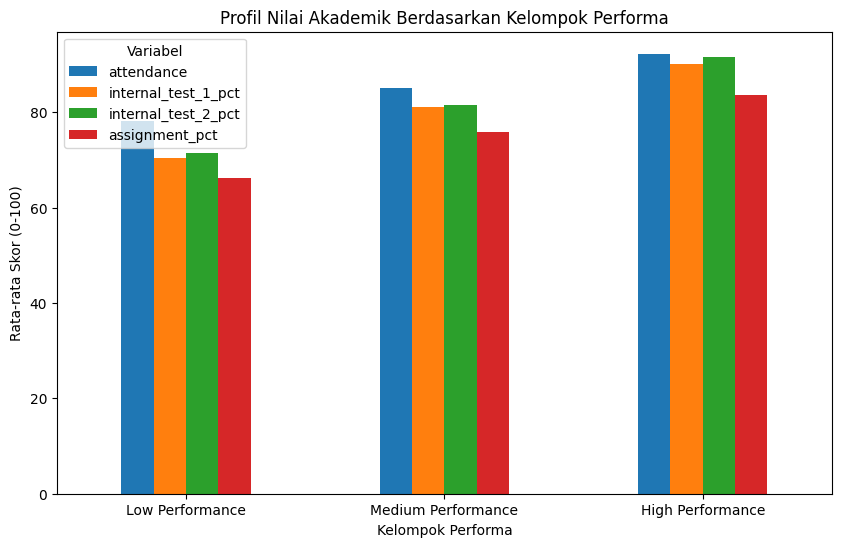

In [218]:
academic_profile = profile[
    [
        'attendance',
        'internal_test_1_pct',
        'internal_test_2_pct',
        'assignment_pct'
    ]
]

academic_profile.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Profil Nilai Akademik Berdasarkan Kelompok Performa')
plt.xlabel('Kelompok Performa')
plt.ylabel('Rata-rata Skor (0-100)')
plt.xticks(rotation=0)
plt.legend(title='Variabel')
plt.show()

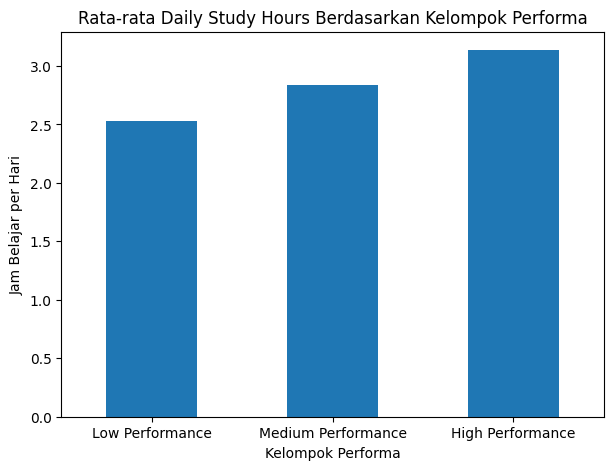

In [219]:
study_profile = profile[['daily_study_hours']]

study_profile.plot(
    kind='bar',
    figsize=(7, 5)
)

plt.title('Rata-rata Daily Study Hours Berdasarkan Kelompok Performa')
plt.xlabel('Kelompok Performa')
plt.ylabel('Jam Belajar per Hari')
plt.xticks(rotation=0)
plt.legend().set_visible(False)
plt.show()

### Insight Profil Siswa Berdasarkan Performa

**Evidence:**

Berdasarkan distribusi nilai `Final Exam`, batas kuartil yang digunakan adalah
**Q1 = 58** dan **Q3 = 73**. Dari pengelompokan tersebut terdapat **556 siswa**
pada kategori Low Performance, **966 siswa** pada Medium Performance, dan
**478 siswa** pada High Performance.

Rata-rata indikator pada kelompok Low Performance adalah `attendance` sebesar
**78,08%**, `Internal Test 1` sebesar **70,46**, `Internal Test 2` sebesar
**71,43**, `Assignment` sebesar **66,26**, dan `daily_study_hours` sebesar
**2,53 jam per hari**. Sementara itu, kelompok High Performance memiliki
rata-rata `attendance` sebesar **92,28%**, `Internal Test 1` sebesar **90,20**,
`Internal Test 2` sebesar **91,64**, `Assignment` sebesar **83,62**, dan
`daily_study_hours` sebesar **3,14 jam per hari**.

**Trend Analysis:**

Terlihat pola peningkatan yang konsisten dari kelompok Low Performance ke
High Performance. Rata-rata `attendance` meningkat sebesar **14,20 poin
persentase**, `Internal Test 1` meningkat **19,74 poin**, `Internal Test 2`
meningkat **20,21 poin**, dan `Assignment` meningkat **17,36 poin**.

Selain indikator akademik, `daily_study_hours` juga meningkat dari **2,53 jam**
menjadi **3,14 jam per hari**, atau bertambah sekitar **0,61 jam per hari**.
Pada saat yang sama, rata-rata `Final Exam` meningkat dari **50,88** pada
kelompok Low Performance menjadi **79,55** pada kelompok High Performance,
atau selisih sebesar **28,67 poin**.

**Actionable Insight:**

Pola tersebut menunjukkan bahwa siswa dengan performa Final Exam yang lebih
tinggi secara deskriptif juga memiliki rata-rata attendance, nilai internal
test, assignment, dan waktu belajar yang lebih tinggi. Oleh karena itu,
variabel `attendance`, `internal_test_1_pct`, `internal_test_2_pct`,
`assignment_pct`, dan `daily_study_hours` relevan untuk digunakan sebagai
fitur dalam model prediksi.

Hasil ini bersifat **deskriptif**, sehingga peningkatan pada suatu indikator
tidak dapat diinterpretasikan sebagai hubungan sebab-akibat secara langsung.

# **6. Feature Engineering**

## **6.1 Academic Average**

Feature `academic_average` dibuat untuk merepresentasikan performa akademik
siswa secara agregat berdasarkan `internal_test_1_pct`, `internal_test_2_pct`,
dan `assignment_pct`.

Ketiga komponen telah dikonversi ke skala 0–100 sehingga dapat digabungkan
dalam satu nilai rata-rata.

In [220]:
# Feature Engineering: Academic Average

df['academic_average'] = (
    df['internal_test_1_pct'] +
    df['internal_test_2_pct'] +
    df['assignment_pct']
) / 3

df[
    [
        'internal_test_1_pct',
        'internal_test_2_pct',
        'assignment_pct',
        'academic_average'
    ]
].head()

,internal_test_1_pct,internal_test_2_pct,assignment_pct,academic_average
0,75.0,90.0,70.0,78.333333
1,60.0,95.0,60.0,71.666667
2,72.5,65.0,70.0,69.166667
3,90.0,87.5,70.0,82.500000
4,77.5,92.5,80.0,83.333333


In [221]:
df['academic_average'].describe()

,academic_average
count,2000.000000
mean,78.840000
std,8.741279
min,49.166667
25%,72.500000
50%,79.166667
75%,85.000000
max,100.000000


In [222]:
df[['academic_average', 'final_exam']].corr()

,academic_average,final_exam
academic_average,1.000000,0.858442
final_exam,0.858442,1.000000


In [223]:
feature_corr = df[
    [
        'attendance',
        'internal_test_1_pct',
        'internal_test_2_pct',
        'assignment_pct',
        'daily_study_hours',
        'academic_average',
        'final_exam'
    ]
].corr()['final_exam'].sort_values(ascending=False)

feature_corr

,final_exam
final_exam,1.000000
academic_average,0.858442
attendance,0.725644
internal_test_2_pct,0.691049
internal_test_1_pct,0.689227
assignment_pct,0.669400
daily_study_hours,0.412877


### Insight

**Evidence:**

Fitur `academic_average` dibentuk dari rata-rata `internal_test_1_pct`,
`internal_test_2_pct`, dan `assignment_pct` yang telah dikonversi ke skala
0–100. Berdasarkan statistik deskriptif, `academic_average` memiliki rata-rata
sebesar **78,84**, standar deviasi **8,74**, nilai minimum **49,17**, dan
nilai maksimum **100** pada **2.000 siswa**.

Hasil analisis korelasi menunjukkan bahwa `academic_average` memiliki korelasi
sebesar **0,8584** dengan `Final Exam`.

**Trend Analysis:**

Nilai korelasi **0,8584** menunjukkan adanya hubungan linear positif yang kuat
antara `academic_average` dan `Final Exam`. Dibandingkan beberapa fitur
individual, nilai tersebut juga lebih tinggi daripada korelasi `attendance`
sebesar **0,7256**, `internal_test_2_pct` sebesar **0,6910**,
`internal_test_1_pct` sebesar **0,6892**, `assignment_pct` sebesar **0,6694**,
dan `daily_study_hours` sebesar **0,4129**.

**Actionable Insight:**

`academic_average` dapat digunakan sebagai fitur agregat untuk merepresentasikan
performa akademik siswa secara lebih ringkas. Korelasi **0,8584** menunjukkan
bahwa fitur ini memiliki hubungan yang kuat dengan `Final Exam`, sehingga
layak diuji dalam eksperimen feature engineering untuk melihat apakah
penambahannya dapat meningkatkan performa model.

Namun, korelasi tersebut bersifat observasional dan tidak menunjukkan hubungan
sebab-akibat. Peningkatan performa model tetap harus dibuktikan melalui
evaluasi pemodelan.

## **6.2 Assessment Average**

Feature `assessment_average` dibuat untuk merepresentasikan rata-rata
performa siswa pada `internal_test_1_pct` dan `internal_test_2_pct`.

Fitur ini digunakan sebagai fitur agregat tambahan dalam eksperimen
feature engineering untuk mengetahui apakah penggabungan dua nilai
internal test dapat membantu proses prediksi Final Exam.

In [224]:
# Rata-rata dua internal test

df['assessment_average'] = (
    df['internal_test_1_pct'] +
    df['internal_test_2_pct']
) / 2

df[
    [
        'internal_test_1_pct',
        'internal_test_2_pct',
        'assessment_average'
    ]
].head(10)

,internal_test_1_pct,internal_test_2_pct,assessment_average
0,75.0,90.0,82.50
1,60.0,95.0,77.50
2,72.5,65.0,68.75
3,90.0,87.5,88.75
4,77.5,92.5,85.00
5,85.0,85.0,85.00
6,100.0,90.0,95.00
7,97.5,92.5,95.00
8,75.0,92.5,83.75
9,67.5,92.5,80.00


In [225]:
engineered_features = [
    'academic_average',
    'assessment_average'
]

df[engineered_features].describe()

,academic_average,assessment_average
count,2000.000000,2000.000000
mean,78.840000,80.725000
std,8.741279,9.027274
min,49.166667,48.750000
25%,72.500000,75.000000
50%,79.166667,81.250000
75%,85.000000,87.500000
max,100.000000,100.000000


### Insight

**Evidence:**

Fitur `assessment_average` dibentuk dari rata-rata `internal_test_1_pct` dan
`internal_test_2_pct`. Berdasarkan **2.000 observasi**, `assessment_average`
memiliki nilai rata-rata sebesar **80,73**, standar deviasi **9,03**, nilai
minimum **48,75**, dan maksimum **100**.

Hasil analisis korelasi menunjukkan bahwa `assessment_average` memiliki korelasi
sebesar **0,8683** dengan `Final Exam`.

**Trend Analysis:**

Nilai korelasi **0,8683** menunjukkan adanya hubungan linear positif yang kuat
antara `assessment_average` dan `Final Exam`. Nilai ini juga sedikit lebih
tinggi dibandingkan korelasi `academic_average` sebesar **0,8584**.

Dibandingkan fitur individual, korelasi `assessment_average` juga lebih tinggi
daripada `attendance` sebesar **0,7256**, `internal_test_2_pct` sebesar
**0,6910**, `internal_test_1_pct` sebesar **0,6892**, `assignment_pct` sebesar
**0,6694**, dan `daily_study_hours` sebesar **0,4129**.

**Actionable Insight:**

`assessment_average` dapat digunakan sebagai fitur agregat untuk merangkum
performa dua internal test dalam satu variabel. Dengan korelasi sebesar
**0,8683**, fitur ini menunjukkan hubungan yang kuat dengan `Final Exam` dan
layak diuji sebagai fitur tambahan dalam eksperimen pemodelan.

Namun, korelasi yang tinggi tidak secara langsung menunjukkan bahwa fitur
tersebut akan meningkatkan performa model. Dampaknya perlu dibuktikan melalui
perbandingan performa model pada tahap eksperimen.

## **6.3 Validasi Fitur Hasil Rekayasa**

Tahap validasi dilakukan untuk memastikan fitur hasil rekayasa memiliki nilai
yang valid, tidak menghasilkan missing value baru, dan dapat digunakan dalam
eksperimen pemodelan.

In [226]:
engineered_columns = [
    'academic_average',
    'assessment_average'
]

print("Missing value pada fitur hasil rekayasa:")
print(df[engineered_columns].isnull().sum())

print("\nRingkasan fitur hasil rekayasa:")
print(df[engineered_columns].describe())

print("\nKorelasi dengan Final Exam:")
print(
    df[
        [
            'attendance',
            'internal_test_1_pct',
            'internal_test_2_pct',
            'assignment_pct',
            'daily_study_hours',
            'academic_average',
            'assessment_average',
            'final_exam'
        ]
    ].corr()['final_exam'].sort_values(ascending=False)
)

Missing value pada fitur hasil rekayasa:
academic_average      0
assessment_average    0
dtype: int64

Ringkasan fitur hasil rekayasa:
       academic_average  assessment_average
count       2000.000000         2000.000000
mean          78.840000           80.725000
std            8.741279            9.027274
min           49.166667           48.750000
25%           72.500000           75.000000
50%           79.166667           81.250000
75%           85.000000           87.500000
max          100.000000          100.000000

Korelasi dengan Final Exam:
final_exam             1.000000
assessment_average     0.868311
academic_average       0.858442
attendance             0.725644
internal_test_2_pct    0.691049
internal_test_1_pct    0.689227
assignment_pct         0.669400
daily_study_hours      0.412877
Name: final_exam, dtype: float64


### Insight

**Evidence:**

Hasil validasi menunjukkan bahwa kedua fitur hasil rekayasa tidak menghasilkan
missing value baru. Nilai missing value pada `academic_average` adalah **0** dan
pada `assessment_average` juga **0**, sehingga seluruh **2.000 observasi** dapat
digunakan untuk eksperimen pemodelan.

Secara statistik, `academic_average` memiliki rata-rata sebesar **78,84** dengan
standar deviasi **8,74**, sedangkan `assessment_average` memiliki rata-rata
sebesar **80,73** dengan standar deviasi **9,03**.

**Trend Analysis:**

Kedua fitur menunjukkan hubungan linear positif yang kuat dengan `Final Exam`.
`academic_average` memiliki korelasi sebesar **0,8584**, sedangkan
`assessment_average` memiliki korelasi sebesar **0,8683**.

Korelasi `assessment_average` lebih tinggi sebesar sekitar **0,0099** dibandingkan
`academic_average`. Keduanya juga memiliki korelasi lebih tinggi dibandingkan
fitur individual seperti `attendance` sebesar **0,7256`,
`internal_test_2_pct` sebesar **0,6910**, `internal_test_1_pct` sebesar
**0,6892**, `assignment_pct` sebesar **0,6694**, dan `daily_study_hours`
sebesar **0,4129**.

**Actionable Insight:**

Hasil validasi menunjukkan bahwa kedua fitur agregat memiliki nilai yang valid
dan hubungan yang kuat dengan `Final Exam`, sehingga keduanya layak digunakan
dalam eksperimen feature engineering.

Namun, korelasi yang tinggi belum membuktikan bahwa penambahan fitur tersebut
akan meningkatkan performa model. Dampaknya perlu dinilai melalui perbandingan
performa antara model baseline dengan model yang menggunakan fitur hasil
rekayasa.

# **7. Model Development – Train/Test Split**

In [227]:
# Target
y = df['final_exam']

# Fitur baseline
baseline_features = [
    'attendance',
    'internal_test_1_pct',
    'internal_test_2_pct',
    'assignment_pct',
    'daily_study_hours'
]

# Fitur dengan feature engineering
engineered_features = [
    'attendance',
    'internal_test_1_pct',
    'internal_test_2_pct',
    'assignment_pct',
    'daily_study_hours',
    'academic_average',
    'assessment_average'
]

X_baseline = df[baseline_features]
X_engineered = df[engineered_features]

print("Target        :", y.shape)
print("Baseline      :", X_baseline.shape)
print("Engineered    :", X_engineered.shape)

Target        : (2000,)
Baseline      : (2000, 5)
Engineered    : (2000, 7)


In [228]:
# Membagi data baseline menjadi training dan testing

X_base_train, X_base_test, y_train, y_test = train_test_split(
    X_baseline,
    y,
    test_size=0.20,
    random_state=42
)

# Menggunakan index yang sama untuk data engineered
X_eng_train = X_engineered.loc[X_base_train.index]
X_eng_test = X_engineered.loc[X_base_test.index]

In [229]:
print("Baseline:")
print("Training :", X_base_train.shape)
print("Testing  :", X_base_test.shape)

print("\nEngineered:")
print("Training :", X_eng_train.shape)
print("Testing  :", X_eng_test.shape)

print("\nTarget:")
print("Training :", y_train.shape)
print("Testing  :", y_test.shape)

Baseline:
Training : (1600, 5)
Testing  : (400, 5)

Engineered:
Training : (1600, 7)
Testing  : (400, 7)

Target:
Training : (1600,)
Testing  : (400,)


## **7.1 Baseline Linear Regression**

In [230]:
# Baseline Model
baseline_model = LinearRegression()

# Training menggunakan data training
baseline_model.fit(X_base_train, y_train)

print("Baseline Linear Regression")
print("--------------------------")
print("Model berhasil dilatih menggunakan 1.600 data training.")

Baseline Linear Regression
--------------------------
Model berhasil dilatih menggunakan 1.600 data training.


### Insight

**Evidence:**

Baseline Linear Regression dilatih menggunakan **1.600 data training** dengan
lima fitur utama, yaitu `attendance`, `internal_test_1_pct`,
`internal_test_2_pct`, `assignment_pct`, dan `daily_study_hours`.

**Trend Analysis:**

Model baseline digunakan sebagai titik acuan sebelum menambahkan fitur hasil
rekayasa. Evaluasi performanya dilakukan menggunakan **5-Fold Cross Validation**
pada data training, sehingga performa model dapat dibandingkan secara konsisten.

**Actionable Insight:**

Baseline ini menjadi acuan untuk menentukan apakah penambahan
`academic_average` dan `assessment_average` memberikan perubahan terhadap
performa prediksi `Final Exam`.

In [231]:
# 5-Fold Cross Validation
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

## **7.2 Eksperimen Feature Engineering**

In [232]:
# Engineered Model
engineered_model = LinearRegression()

# Evaluasi feature engineering menggunakan 5-Fold Cross Validation
engineered_cv = cross_validate(
    engineered_model,
    X_eng_train,
    y_train,
    cv=cv,
    scoring={
        'MAE': 'neg_mean_absolute_error',
        'RMSE': 'neg_root_mean_squared_error',
        'R2': 'r2'
    }
)

mae_engineered_cv = -engineered_cv['test_MAE']
rmse_engineered_cv = -engineered_cv['test_RMSE']
r2_engineered_cv = engineered_cv['test_R2']

print("Engineered Linear Regression - 5-Fold CV")
print("------------------------------------------")
print(
    "MAE  :",
    round(mae_engineered_cv.mean(), 3),
    "±",
    round(mae_engineered_cv.std(), 3)
)
print(
    "RMSE :",
    round(rmse_engineered_cv.mean(), 3),
    "±",
    round(rmse_engineered_cv.std(), 3)
)
print(
    "R²   :",
    round(r2_engineered_cv.mean(), 3),
    "±",
    round(r2_engineered_cv.std(), 3)
)

Engineered Linear Regression - 5-Fold CV
------------------------------------------
MAE  : 3.606 ± 0.094
RMSE : 4.577 ± 0.122
R²   : 0.837 ± 0.007


### Insight

**Evidence:**

Hasil 5-Fold Cross Validation pada model Linear Regression dengan fitur hasil
rekayasa menghasilkan **MAE sebesar 3,606 ± 0,094**, **RMSE sebesar
4,577 ± 0,122**, dan **R² sebesar 0,837 ± 0,007**.

**Trend Analysis:**

Fitur `academic_average` dan `assessment_average` ditambahkan ke lima fitur
baseline sehingga model menggunakan total **7 fitur**. Hasil evaluasi
menunjukkan performa prediksi berada pada RMSE rata-rata **4,577** dan R²
rata-rata **0,837** pada 5-fold validation.

**Actionable Insight:**

Fitur hasil rekayasa layak dipertahankan dalam eksperimen karena memberikan
representasi agregat terhadap performa akademik siswa. Namun, dampak
penambahannya perlu dibandingkan secara langsung dengan baseline menggunakan
metrik yang sama sebelum menentukan konfigurasi model final.

## **7.3 Model Pembanding**

In [233]:

# =========================
# RANDOM FOREST
# =========================

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_base_train, y_train)

y_pred_rf = rf_model.predict(X_base_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)


# =========================
# GRADIENT BOOSTING
# =========================

gb_model = GradientBoostingRegressor(
    n_estimators=100,
    random_state=42
)

gb_model.fit(X_base_train, y_train)

y_pred_gb = gb_model.predict(X_base_test)

mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)


# =========================
# HASIL
# =========================

print("Random Forest")
print("----------------")
print("MAE  :", round(mae_rf, 3))
print("RMSE :", round(rmse_rf, 3))
print("R²   :", round(r2_rf, 3))

print("\nGradient Boosting")
print("----------------")
print("MAE  :", round(mae_gb, 3))
print("RMSE :", round(rmse_gb, 3))
print("R²   :", round(r2_gb, 3))

Random Forest
----------------
MAE  : 4.151
RMSE : 5.234
R²   : 0.781

Gradient Boosting
----------------
MAE  : 3.737
RMSE : 4.786
R²   : 0.817


In [234]:
# Decision Tree Model
decision_tree_model = DecisionTreeRegressor(
    random_state=42,
    max_depth=5
)

# Training
decision_tree_model.fit(X_base_train, y_train)

# Prediksi
y_pred_dt = decision_tree_model.predict(X_base_test)

# Evaluasi
mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)

print("DECISION TREE REGRESSION")
print("========================")
print("MAE  :", round(mae_dt, 3))
print("RMSE :", round(rmse_dt, 3))
print("R²   :", round(r2_dt, 3))

DECISION TREE REGRESSION
MAE  : 4.741
RMSE : 5.965
R²   : 0.716


### Insight

**Evidence:**

Evaluasi pada data testing menunjukkan bahwa Random Forest menghasilkan
**MAE 4,151**, **RMSE 5,234**, dan **R² 0,781**. Gradient Boosting menghasilkan
**MAE 3,737**, **RMSE 4,786**, dan **R² 0,817**. Sementara itu, Decision Tree
menghasilkan **MAE 4,741**, **RMSE 5,965**, dan **R² 0,716**.

**Trend Analysis:**

Gradient Boosting menghasilkan error yang lebih rendah dibandingkan Random
Forest dan Decision Tree pada pengujian ini, dengan RMSE **4,786** dan R²
**0,817**. Decision Tree menunjukkan RMSE tertinggi sebesar **5,965** dan
R² sebesar **0,716**.

**Actionable Insight:**

Hasil ini menunjukkan adanya perbedaan performa antar pendekatan regresi.
Namun, hasil pada data testing digunakan sebagai analisis pembanding saja.
Pemilihan model final tetap dilakukan berdasarkan **5-Fold Cross Validation
pada data training** agar data testing tidak menjadi dasar pemilihan model.

## **7.4 5-Fold Cross Validation – Linear Regression**

In [235]:
cv_results = cross_validate(
    baseline_model,
    X_base_train,
    y_train,
    cv=cv,
    scoring={
        'MAE': 'neg_mean_absolute_error',
        'RMSE': 'neg_root_mean_squared_error',
        'R2': 'r2'
    }
)

# Karena MAE dan RMSE dikembalikan dalam bentuk negatif
mae_cv = -cv_results['test_MAE']
rmse_cv = -cv_results['test_RMSE']
r2_cv = cv_results['test_R2']

print("5-Fold Cross Validation - Linear Regression")
print("---------------------------------------------")

print("MAE  :", round(mae_cv.mean(), 3),
      "±", round(mae_cv.std(), 3))

print("RMSE :", round(rmse_cv.mean(), 3),
      "±", round(rmse_cv.std(), 3))

print("R²   :", round(r2_cv.mean(), 3),
      "±", round(r2_cv.std(), 3))

5-Fold Cross Validation - Linear Regression
---------------------------------------------
MAE  : 3.606 ± 0.094
RMSE : 4.577 ± 0.122
R²   : 0.837 ± 0.007


### Insight

**Evidence:**

Hasil **5-Fold Cross Validation** pada Linear Regression menghasilkan
**MAE sebesar 3,606 ± 0,094**, **RMSE sebesar 4,577 ± 0,122**, dan
**R² sebesar 0,837 ± 0,007**.

**Trend Analysis:**

Standar deviasi setiap metrik relatif kecil, yaitu **0,094** untuk MAE,
**0,122** untuk RMSE, dan **0,007** untuk R². Hal ini menunjukkan bahwa
performa Linear Regression relatif konsisten pada lima fold training.

**Actionable Insight:**

Hasil 5-Fold Cross Validation ini digunakan sebagai baseline evaluasi untuk
membandingkan performa Linear Regression dengan model regresi lainnya pada
tahap berikutnya.

## **7.5 Cross Validation – Model Comparison**

In [165]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=100,
        random_state=42
    )
}

results = []

for name, model in models.items():

    cv_result = cross_validate(
        model,
        X_base_train,
        y_train,
        cv=cv,
        scoring={
            'MAE': 'neg_mean_absolute_error',
            'RMSE': 'neg_root_mean_squared_error',
            'R2': 'r2'
        }
    )

    results.append({
        'Model': name,
        'MAE Mean': -cv_result['test_MAE'].mean(),
        'MAE Std': cv_result['test_MAE'].std(),
        'RMSE Mean': -cv_result['test_RMSE'].mean(),
        'RMSE Std': cv_result['test_RMSE'].std(),
        'R2 Mean': cv_result['test_R2'].mean(),
        'R2 Std': cv_result['test_R2'].std()
    })

cv_comparison = pd.DataFrame(results)

cv_comparison.round(3)

,Model,MAE Mean,MAE Std,RMSE Mean,RMSE Std,R2 Mean,R2 Std
0,Linear Regression,3.606,0.094,4.577,0.122,0.837,0.007
1,Random Forest,4.052,0.059,5.137,0.091,0.795,0.006
2,Gradient Boosting,3.883,0.082,4.902,0.115,0.814,0.006


### Insight

**Evidence:**

Hasil 5-Fold Cross Validation pada Linear Regression menghasilkan
**MAE sebesar 3,606 ± 0,094**, **RMSE sebesar 4,577 ± 0,122**, dan
**R² sebesar 0,837 ± 0,007**.

**Trend Analysis:**

Nilai standar deviasi yang relatif kecil, yaitu **0,094** untuk MAE,
**0,122** untuk RMSE, dan **0,007** untuk R², menunjukkan bahwa performa
model relatif konsisten pada lima fold training.

**Actionable Insight:**

Hasil Cross Validation ini digunakan sebagai baseline evaluasi yang konsisten
untuk membandingkan Linear Regression dengan model regresi lainnya. Nilai
**RMSE 4,577** dan **R² 0,837** menjadi acuan pada tahap pemilihan model
berikutnya.

## **7.6 Learning Curve**

Learning Curve digunakan untuk melihat pengaruh jumlah data training terhadap performa model Linear Regression. Analisis ini membantu mengetahui apakah model mengalami overfitting atau underfitting serta apakah penambahan data training berpotensi meningkatkan performa model.

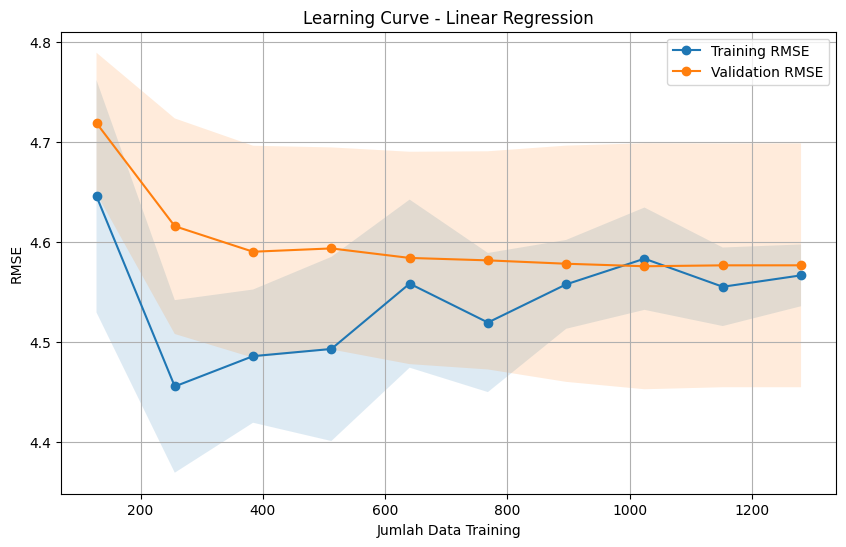


Learning Curve Summary
----------------------
Data training terbesar : 1280
Training RMSE terakhir : 4.567
Validation RMSE terakhir : 4.577
RMSE gap terakhir      : 0.01


In [166]:
# Model yang dianalisis
learning_curve_model = LinearRegression()

# Learning curve menggunakan training set saja
train_sizes, train_scores, validation_scores = learning_curve(
    learning_curve_model,
    X_base_train,
    y_train,
    cv=cv,
    scoring='neg_root_mean_squared_error',
    train_sizes=np.linspace(0.1, 1.0, 10),
    random_state=42
)

# Konversi nilai negatif RMSE menjadi RMSE positif
train_rmse = -train_scores
validation_rmse = -validation_scores

# Rata-rata dan standar deviasi
train_mean = train_rmse.mean(axis=1)
train_std = train_rmse.std(axis=1)

validation_mean = validation_rmse.mean(axis=1)
validation_std = validation_rmse.std(axis=1)

# Visualisasi
plt.figure(figsize=(10, 6))

plt.plot(
    train_sizes,
    train_mean,
    marker='o',
    label='Training RMSE'
)

plt.plot(
    train_sizes,
    validation_mean,
    marker='o',
    label='Validation RMSE'
)

plt.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.15
)

plt.fill_between(
    train_sizes,
    validation_mean - validation_std,
    validation_mean + validation_std,
    alpha=0.15
)

plt.xlabel('Jumlah Data Training')
plt.ylabel('RMSE')
plt.title('Learning Curve - Linear Regression')
plt.legend()
plt.grid(True)

plt.show()

print("\nLearning Curve Summary")
print("----------------------")
print("Data training terbesar :", train_sizes[-1])
print("Training RMSE terakhir :", round(train_mean[-1], 3))
print("Validation RMSE terakhir :", round(validation_mean[-1], 3))
print("RMSE gap terakhir      :", round(validation_mean[-1] - train_mean[-1], 3))

### Insight

**Evidence:**

Pada jumlah data training terbesar, yaitu **1.280 data**, Linear Regression
menghasilkan **Training RMSE sebesar 4,567** dan **Validation RMSE sebesar
4,577**. Selisih antara keduanya hanya sebesar **0,010**.

**Trend Analysis:**

Training RMSE dan Validation RMSE semakin mendekati seiring bertambahnya
jumlah data training. Pada ukuran training terbesar, gap RMSE hanya **0,01**,
yang menunjukkan bahwa performa model pada data training dan validation berada
pada tingkat yang sangat berdekatan.

**Actionable Insight:**

Learning Curve menunjukkan tidak adanya indikasi overfitting yang signifikan
pada konfigurasi baseline Linear Regression. Dengan **1.280 data training**,
perbedaan Training RMSE (**4,567**) dan Validation RMSE (**4,577**) sangat
kecil sehingga model menunjukkan performa yang relatif stabil.

## **7.7 Hyperparameter Tuning**

Hyperparameter tuning dilakukan untuk memperoleh konfigurasi model yang memberikan performa terbaik. Proses tuning dilakukan hanya menggunakan data training dengan 5-Fold Cross Validation untuk menjaga data testing tetap tidak terlibat dalam proses pemilihan model.

Model yang dituning adalah Random Forest, Gradient Boosting, dan Decision Tree. Linear Regression digunakan sebagai baseline karena tidak memiliki hyperparameter utama yang perlu dioptimalkan.

In [167]:

# ==========================================
# 1. RANDOM FOREST
# ==========================================

rf = RandomForestRegressor(
    random_state=42
)

rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_grid = GridSearchCV(
    estimator=rf,
    param_grid=rf_param_grid,
    cv=cv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

rf_grid.fit(X_base_train, y_train)


# ==========================================
# 2. GRADIENT BOOSTING
# ==========================================

gb = GradientBoostingRegressor(
    random_state=42
)

gb_param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.03, 0.05, 0.1],
    'max_depth': [2, 3, 4],
    'min_samples_split': [2, 5]
}

gb_grid = GridSearchCV(
    estimator=gb,
    param_grid=gb_param_grid,
    cv=cv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

gb_grid.fit(X_base_train, y_train)


# ==========================================
# 3. DECISION TREE
# ==========================================

dt = DecisionTreeRegressor(
    random_state=42
)

dt_param_grid = {
    'max_depth': [3, 4, 5, 6, 8, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

dt_grid = GridSearchCV(
    estimator=dt,
    param_grid=dt_param_grid,
    cv=cv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

dt_grid.fit(X_base_train, y_train)


print("Hyperparameter tuning selesai.")

Hyperparameter tuning selesai.


In [168]:
print("BEST RANDOM FOREST")
print("==================")
print("Best Parameters :", rf_grid.best_params_)
print("Best CV RMSE    :", round(-rf_grid.best_score_, 3))

print("\nBEST GRADIENT BOOSTING")
print("======================")
print("Best Parameters :", gb_grid.best_params_)
print("Best CV RMSE    :", round(-gb_grid.best_score_, 3))

print("\nBEST DECISION TREE")
print("==================")
print("Best Parameters :", dt_grid.best_params_)
print("Best CV RMSE    :", round(-dt_grid.best_score_, 3))

BEST RANDOM FOREST
Best Parameters : {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 300}
Best CV RMSE    : 4.988

BEST GRADIENT BOOSTING
Best Parameters : {'learning_rate': 0.05, 'max_depth': 2, 'min_samples_split': 2, 'n_estimators': 200}
Best CV RMSE    : 4.833

BEST DECISION TREE
Best Parameters : {'max_depth': 8, 'min_samples_leaf': 4, 'min_samples_split': 10}
Best CV RMSE    : 5.691


### Insight

**Evidence:**

Hyperparameter tuning dilakukan pada Random Forest, Gradient Boosting, dan
Decision Tree menggunakan **5-Fold Cross Validation** pada data training.

Hasil tuning menghasilkan **CV RMSE 4,988** untuk Random Forest,
**4,833** untuk Gradient Boosting, dan **5,691** untuk Decision Tree.

**Trend Analysis:**

Setelah tuning, Gradient Boosting menghasilkan CV RMSE sebesar **4,833**,
sedangkan Random Forest **4,988** dan Decision Tree **5,691**.

Dibandingkan hasil Cross Validation sebelum tuning, Random Forest berubah dari
**5,137 menjadi 4,988**, atau turun sebesar **0,149 poin**. Gradient Boosting
berubah dari **4,902 menjadi 4,833**, atau turun sebesar **0,069 poin**.

**Actionable Insight:**

Hyperparameter tuning memberikan perbaikan RMSE pada Random Forest dan
Gradient Boosting. Hasil tuning ini kemudian dibandingkan dengan Linear
Regression yang memiliki CV RMSE **4,577** untuk menentukan model yang
digunakan pada tahap akhir.

## **7.8 Perbandingan Hasil Tuning**

In [169]:
lr_cv = cross_validate(
    LinearRegression(),
    X_base_train,
    y_train,
    cv=cv,
    scoring='neg_root_mean_squared_error'
)

lr_rmse = -lr_cv['test_score'].mean()

tuning_results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest Tuned',
        'Gradient Boosting Tuned',
        'Decision Tree Tuned'
    ],
    'CV RMSE': [
        lr_rmse,
        -rf_grid.best_score_,
        -gb_grid.best_score_,
        -dt_grid.best_score_
    ]
}).sort_values('CV RMSE')

tuning_results

,Model,CV RMSE
0,Linear Regression,4.576915
2,Gradient Boosting Tuned,4.833368
1,Random Forest Tuned,4.987619
3,Decision Tree Tuned,5.690991


### Insight

**Evidence:**

Hasil **5-Fold Cross Validation** menunjukkan bahwa Linear Regression
memiliki **CV RMSE sebesar 4,5769**. Gradient Boosting Tuned menghasilkan
**4,8334**, Random Forest Tuned **4,9876**, dan Decision Tree Tuned
**5,6910**.

**Trend Analysis:**

Linear Regression memiliki CV RMSE **0,2565 poin lebih rendah** dibandingkan
Gradient Boosting Tuned. Dibandingkan Random Forest Tuned, selisihnya sebesar
**0,4107 poin**, sedangkan dibandingkan Decision Tree Tuned sebesar
**1,1141 poin**.

Hasil tersebut menunjukkan bahwa pada konfigurasi dan data training yang
digunakan, Linear Regression menghasilkan error prediksi Cross Validation yang
lebih rendah dibandingkan tiga model yang telah melalui hyperparameter tuning.

**Actionable Insight:**

Hasil Cross Validation digunakan sebagai dasar pemilihan kandidat model.
Linear Regression kemudian digunakan sebagai **model final** dan dievaluasi
pada data testing yang belum digunakan dalam proses training maupun pemilihan
model.

Evaluasi final pada data testing dilakukan pada Section 8 untuk melihat
performa model pada data yang benar-benar belum digunakan sebelumnya.

### **Model Selection**

Berdasarkan hasil 5-Fold Cross Validation, Linear Regression memberikan performa terbaik dengan nilai RMSE sebesar 4.5769. Hasil ini lebih rendah dibandingkan Gradient Boosting yang telah melalui hyperparameter tuning (4.8334), Random Forest yang telah dituning (4.9876), dan Decision Tree yang telah dituning (5.6910). Dengan demikian, Linear Regression dipilih sebagai kandidat model terbaik untuk memprediksi nilai ujian akhir siswa.

# **8. Final Model**

In [170]:
# ==========================================
# FINAL MODEL - LINEAR REGRESSION
# ==========================================

final_model = LinearRegression()

# Training hanya menggunakan 1.600 data training
final_model.fit(X_base_train, y_train)

# Prediksi 400 data test yang belum pernah digunakan
y_pred_final = final_model.predict(X_base_test)

# Evaluasi
mae_final = mean_absolute_error(y_test, y_pred_final)
rmse_final = np.sqrt(mean_squared_error(y_test, y_pred_final))
r2_final = r2_score(y_test, y_pred_final)

print("FINAL MODEL - LINEAR REGRESSION")
print("================================")
print("MAE  :", round(mae_final, 3))
print("RMSE :", round(rmse_final, 3))
print("R²   :", round(r2_final, 3))

FINAL MODEL - LINEAR REGRESSION
MAE  : 3.675
RMSE : 4.618
R²   : 0.83


## **8.1 Evaluasi Final Model**

Linear Regression digunakan sebagai model final berdasarkan hasil
perbandingan Cross Validation pada data training. Model kemudian dievaluasi
menggunakan 400 data testing yang tidak digunakan selama proses pelatihan
dan pemilihan model.

Pada data testing, model menghasilkan MAE sebesar **3,675**, RMSE sebesar
**4,618**, dan R² sebesar **0,830**.

### Insight

**Evidence:**

Linear Regression digunakan sebagai model final dengan lima fitur, yaitu
`attendance`, `internal_test_1_pct`, `internal_test_2_pct`, `assignment_pct`,
dan `daily_study_hours`.

Pada **400 data testing**, model menghasilkan **MAE sebesar 3,675**,
**RMSE sebesar 4,618**, dan **R² sebesar 0,830**.

**Trend Analysis:**

Nilai MAE sebesar **3,675** menunjukkan bahwa rata-rata selisih absolut antara
nilai Final Exam aktual dan hasil prediksi adalah sekitar **3,675 poin**.
Sementara itu, RMSE sebesar **4,618** menunjukkan besarnya error prediksi
dengan penalti yang lebih besar terhadap kesalahan yang lebih tinggi.

Nilai **R² sebesar 0,830** menunjukkan bahwa model dapat menjelaskan sekitar
**83,0% variasi nilai Final Exam** pada data testing.

**Actionable Insight:**

Hasil evaluasi menunjukkan bahwa Linear Regression dapat digunakan untuk
menghasilkan prediksi nilai Final Exam yang kemudian menjadi dasar bagi
analisis Early Warning EduPulse.

Data testing tetap digunakan hanya untuk **evaluasi akhir**, sehingga tidak
terlibat dalam proses training maupun pemilihan model.

# **9. Early Warning Risk Analysis**

In [171]:
# ==========================================
# ANALISIS NILAI UNTUK RISK CLASSIFICATION
# ==========================================

risk_analysis = pd.DataFrame({
    'actual_final': y_test.values,
    'predicted_final': y_pred_final
})

print("Statistik nilai aktual:")
print(risk_analysis['actual_final'].describe())

print("\nStatistik nilai prediksi:")
print(risk_analysis['predicted_final'].describe())

Statistik nilai aktual:
count    400.000000
mean      64.860000
std       11.205101
min       31.000000
25%       57.750000
50%       65.000000
75%       73.000000
max       94.000000
Name: actual_final, dtype: float64

Statistik nilai prediksi:
count    400.000000
mean      65.052035
std       10.209219
min       26.429257
25%       58.156941
50%       65.772319
75%       72.286673
max       89.670642
Name: predicted_final, dtype: float64


## **9.1 Kuartil Nilai Aktual dan Prediksi**

In [172]:
print("\nKuartil nilai aktual:")
print(risk_analysis['actual_final'].quantile([0.25, 0.50, 0.75]))

print("\nKuartil nilai prediksi:")
print(risk_analysis['predicted_final'].quantile([0.25, 0.50, 0.75]))


Kuartil nilai aktual:
0.25    57.75
0.50    65.00
0.75    73.00
Name: actual_final, dtype: float64

Kuartil nilai prediksi:
0.25    58.156941
0.50    65.772319
0.75    72.286673
Name: predicted_final, dtype: float64


### Insight

**Evidence:**

Pada **400 data testing**, kuartil nilai `Final Exam` aktual menunjukkan
**Q1 sebesar 57,75**, **median 65,00**, dan **Q3 sebesar 73,00**.

Sementara itu, hasil prediksi model memiliki **Q1 sebesar 58,1569**,
**median 65,7723**, dan **Q3 sebesar 72,2867**.

**Trend Analysis:**

Distribusi nilai prediksi memiliki pola yang dekat dengan distribusi nilai
aktual. Selisih antara Q1 aktual dan prediksi adalah sekitar **0,41 poin**,
selisih median sekitar **0,77 poin**, sedangkan Q3 prediksi sekitar
**0,71 poin lebih rendah** dibandingkan Q3 aktual.

Kedekatan nilai Q1, median, dan Q3 menunjukkan bahwa distribusi hasil prediksi
mengikuti pola distribusi nilai aktual pada data testing.

**Actionable Insight:**

Hasil ini mendukung penggunaan nilai prediksi sebagai dasar untuk melakukan
analisis risiko siswa pada tahap Early Warning. Namun, kedekatan distribusi
kuartil tidak digunakan sebagai satu-satunya ukuran performa model karena
evaluasi model tetap mengacu pada MAE, RMSE, dan R².

## **9.2 Risk Classification untuk Analisis Performa**

Pengelompokan pada bagian ini digunakan hanya untuk analisis deskriptif berdasarkan distribusi nilai prediksi. Batas 58 dan 73 berasal dari kuartil nilai Final Exam dan bukan merupakan threshold operasional Early Warning EduPulse.

Threshold operasional EduPulse yang digunakan untuk klasifikasi risiko final dibahas pada Section 9.4.

In [173]:
# ==========================================
# RISK CLASSIFICATION
# ==========================================

risk_analysis['risk_group'] = pd.cut(
    risk_analysis['predicted_final'],
    bins=[-float('inf'), 58, 73, float('inf')],
    labels=['High Risk', 'Medium Risk', 'Low Risk']
)

risk_analysis['risk_group'].value_counts().sort_index()

,count
risk_group,
High Risk,99
Medium Risk,204
Low Risk,97


### Insight

**Evidence:**

Pengelompokan berdasarkan kuartil nilai prediksi menghasilkan **99 siswa
High Risk**, **204 siswa Medium Risk**, dan **97 siswa Low Risk** dari total
**400 data testing**.

Secara proporsi, kelompok High Risk mencakup **24,75%** data, Medium Risk
**51,00%**, dan Low Risk **24,25%**.

**Trend Analysis:**

Kelompok Medium Risk memiliki jumlah siswa paling besar, yaitu **204 siswa**
atau **51,00%** dari data testing. Sementara itu, jumlah siswa pada High Risk
dan Low Risk relatif berdekatan, yaitu masing-masing **99** dan **97 siswa**.

Distribusi tersebut terbentuk dari batas kuartil **58** dan **73**, sehingga
pengelompokan ini membagi nilai prediksi berdasarkan distribusinya pada data
testing.

**Actionable Insight:**

Pengelompokan ini dapat digunakan untuk memahami distribusi performa siswa
secara deskriptif dan mengevaluasi pola hasil prediksi model.

Namun, kategori ini **bukan threshold operasional Early Warning EduPulse**.
Threshold yang digunakan oleh sistem ditetapkan secara terpisah pada Section
9.4.

## **9.3 Profil Nilai Aktual Berdasarkan Risk Group**

In [174]:
# Membandingkan actual final score berdasarkan risk prediction

risk_profile = risk_analysis.groupby(
    'risk_group',
    observed=True
)['actual_final'].agg(
    ['count', 'mean', 'min', 'max']
)

risk_profile

,count,mean,min,max
risk_group,,,,
High Risk,99,51.373737,31,68
Medium Risk,204,65.171569,47,82
Low Risk,97,77.969072,66,94


### Insight

**Evidence:**

Berdasarkan risk group yang dibentuk dari nilai prediksi, kelompok High Risk
terdiri dari **99 siswa** dengan rata-rata nilai aktual **51,37**, kelompok
Medium Risk terdiri dari **204 siswa** dengan rata-rata **65,17**, dan kelompok
Low Risk terdiri dari **97 siswa** dengan rata-rata **77,97**.

Rentang nilai aktual masing-masing kelompok adalah **31–68** untuk High Risk,
**47–82** untuk Medium Risk, dan **66–94** untuk Low Risk.

**Trend Analysis:**

Rata-rata nilai aktual meningkat dari **51,37** pada High Risk menjadi
**65,17** pada Medium Risk, atau naik sebesar **13,80 poin**.

Dari Medium Risk ke Low Risk, rata-rata meningkat dari **65,17** menjadi
**77,97**, atau sebesar **12,80 poin**.

Secara keseluruhan, terdapat selisih rata-rata sebesar **26,60 poin** antara
kelompok High Risk dan Low Risk.

**Actionable Insight:**

Pola tersebut menunjukkan bahwa pengelompokan berdasarkan nilai prediksi
memiliki keterkaitan yang jelas dengan distribusi nilai aktual pada data
testing. Kelompok dengan prediksi lebih rendah memiliki rata-rata nilai aktual
yang lebih rendah, sedangkan kelompok dengan prediksi lebih tinggi memiliki
rata-rata nilai aktual yang lebih tinggi.

Hasil ini digunakan sebagai validasi deskriptif terhadap pengelompokan risiko
dan bukan sebagai evaluasi klasifikasi operasional.

## **9.4 Risk Threshold Operasional EduPulse**

In [175]:
# Risk Classification berdasarkan batas akademik

risk_analysis['risk_school'] = pd.cut(
    risk_analysis['predicted_final'],
    bins=[-float('inf'), 70, 80, float('inf')],
    labels=['High Risk', 'Medium Risk', 'Low Risk'],
    right=False
)

risk_analysis['risk_school'].value_counts().sort_index()

,count
risk_school,
High Risk,275
Medium Risk,98
Low Risk,27


### Insight

**Evidence:**

Threshold operasional EduPulse mengelompokkan siswa berdasarkan nilai prediksi
Final Exam menjadi tiga kategori, yaitu **High Risk (<70)**, **Medium Risk
(70 hingga <80)**, dan **Low Risk (≥80)**.

Dari **400 data testing**, terdapat **275 siswa High Risk**, **98 siswa
Medium Risk**, dan **27 siswa Low Risk**. Secara proporsi, masing-masing
kategori mencakup **68,75%**, **24,50%**, dan **6,75%** dari data testing.

**Trend Analysis:**

Kategori High Risk mencakup proporsi terbesar, yaitu **68,75%** dari seluruh
data testing. Jumlah ini lebih besar dibandingkan Medium Risk sebesar
**24,50%** dan Low Risk sebesar **6,75%**.

Distribusi tersebut menunjukkan bahwa berdasarkan nilai prediksi model,
sebagian besar siswa pada data testing berada pada rentang nilai prediksi
di bawah 70.

**Actionable Insight:**

Threshold **70 dan 80** digunakan untuk menerjemahkan hasil prediksi numerik
menjadi kategori risiko yang dapat digunakan oleh sistem Early Warning
EduPulse.

Kategori tersebut dapat menjadi dasar penyajian status risiko siswa pada
dashboard, sedangkan detail indikator akademik dapat digunakan sebagai
informasi pendukung untuk tindak lanjut.

## **9.5 Validasi Profil Risiko**

In [176]:
# Validasi risk berdasarkan batas akademik

risk_school_profile = risk_analysis.groupby(
    'risk_school',
    observed=True
)['actual_final'].agg(
    ['count', 'mean', 'min', 'max']
)

risk_school_profile

,count,mean,min,max
risk_school,,,,
High Risk,275,59.545455,31,80
Medium Risk,98,74.867347,62,86
Low Risk,27,82.666667,71,94


### Insight

**Evidence:**

Validasi profil risiko menunjukkan bahwa kelompok **High Risk** terdiri dari
**275 siswa** dengan rata-rata nilai aktual **59,55**, kelompok **Medium
Risk** terdiri dari **98 siswa** dengan rata-rata **74,87**, dan kelompok
**Low Risk** terdiri dari **27 siswa** dengan rata-rata **82,67**.

Rentang nilai aktual pada masing-masing kelompok adalah **31–80** untuk
High Risk, **62–86** untuk Medium Risk, dan **71–94** untuk Low Risk.

**Trend Analysis:**

Rata-rata nilai aktual meningkat dari **59,55** pada High Risk menjadi
**74,87** pada Medium Risk, atau sebesar **15,32 poin**.

Dari Medium Risk ke Low Risk, rata-rata nilai aktual meningkat sebesar
**7,80 poin**, dari **74,87** menjadi **82,67**.

Secara keseluruhan, terdapat selisih rata-rata sebesar **23,12 poin**
antara kelompok High Risk dan Low Risk.

**Actionable Insight:**

Pola rata-rata nilai aktual yang meningkat dari High Risk ke Low Risk
memberikan validasi deskriptif bahwa threshold risiko berbasis nilai prediksi
memiliki pola yang selaras dengan nilai aktual pada data testing.

Hasil ini dapat digunakan sebagai dasar pendukung bahwa kategori risiko
operasional EduPulse memiliki keterkaitan dengan performa aktual siswa.

# **10. Early Warning Model Evaluation**

In [177]:

# ==========================================
# RISK EVALUATION
# ==========================================

# Risiko berdasarkan prediksi model
predicted_risk = pd.cut(
    y_pred_final,
    bins=[-float('inf'), 70, float('inf')],
    labels=['At Risk', 'Not At Risk'],
    right=False
)

# Kondisi aktual berdasarkan nilai sebenarnya
actual_risk = pd.cut(
    y_test,
    bins=[-float('inf'), 70, float('inf')],
    labels=['At Risk', 'Not At Risk'],
    right=False
)

print("Classification Report")
print("======================")
print(classification_report(
    actual_risk,
    predicted_risk,
    target_names=['At Risk', 'Not At Risk']
))

print("\nConfusion Matrix")
print("================")
print(confusion_matrix(
    actual_risk,
    predicted_risk
))

Classification Report
              precision    recall  f1-score   support

     At Risk       0.89      0.94      0.91       261
 Not At Risk       0.87      0.78      0.83       139

    accuracy                           0.89       400
   macro avg       0.88      0.86      0.87       400
weighted avg       0.88      0.89      0.88       400


Confusion Matrix
[[245  16]
 [ 30 109]]


### Insight

**Evidence:**

Evaluasi Early Warning pada **400 data testing** menghasilkan **accuracy
sebesar 89%**.

Untuk kategori **At Risk**, model menghasilkan **precision 89%**, **recall
94%**, dan **F1-score 91%**. Sementara itu, kategori Not At Risk memiliki
precision **87%**, recall **78%**, dan F1-score **83%**.

Confusion matrix menunjukkan **245 siswa At Risk berhasil terdeteksi sebagai
At Risk**, sedangkan **16 siswa At Risk** diprediksi sebagai Not At Risk.
Pada kategori Not At Risk, terdapat **109 prediksi yang benar** dan
**30 siswa** yang diprediksi sebagai At Risk.

**Trend Analysis:**

Recall kategori At Risk sebesar **94%** menunjukkan bahwa dari **261 siswa
yang secara aktual termasuk At Risk**, sebanyak **245 siswa** berhasil
teridentifikasi oleh model.

Sebanyak **16 siswa** tidak terdeteksi sebagai At Risk, sedangkan terdapat
**30 siswa Not At Risk** yang diprediksi sebagai At Risk.

**Actionable Insight:**

Hasil evaluasi menunjukkan bahwa model dapat digunakan untuk mengubah prediksi
nilai Final Exam menjadi informasi **At Risk** dan **Not At Risk** pada
sistem Early Warning.

Recall **94%** pada kategori At Risk menjadi metrik penting karena berkaitan
dengan kemampuan model dalam mengidentifikasi siswa yang secara aktual
memiliki nilai di bawah threshold 70.

Hasil ini merupakan evaluasi pada **400 data testing** dan tidak berarti bahwa
model akan menghasilkan performa yang sama pada populasi siswa lain.

## **10.1 Interpretasi Classification Report**

### Insight

**Evidence:**

Evaluasi pada **400 data testing** menghasilkan **accuracy sebesar 89%**.
Pada kategori `At Risk`, model memperoleh **precision 89%**, **recall 94%**,
dan **F1-score 91%**.

Confusion matrix menunjukkan bahwa **245 dari 261 siswa At Risk** berhasil
teridentifikasi, sedangkan **16 siswa At Risk** tidak terdeteksi.

**Trend Analysis:**

Recall sebesar **94%** menunjukkan bahwa sebagian besar siswa yang secara aktual
berada pada kategori At Risk berhasil diidentifikasi oleh model. Selain itu,
terdapat **30 siswa Not At Risk** yang diprediksi sebagai At Risk.

**Actionable Insight:**

Hasil classification report digunakan untuk mengevaluasi kemampuan komponen
Early Warning dalam menerjemahkan prediksi nilai `Final Exam` menjadi kategori
`At Risk` dan `Not At Risk`.

Perlu dibedakan bahwa **accuracy 89% merupakan metrik klasifikasi Early
Warning**, bukan accuracy dari model regresi. Performa regresi tetap diukur
menggunakan **MAE, RMSE, dan R²**.

# **11. Final Model Export**

## Final Model Export

Model Linear Regression yang telah dipilih berdasarkan hasil cross-validation dan evaluasi final disimpan sebagai artifact untuk digunakan pada sistem EduPulse.

In [178]:
# ==========================================
# FINAL MODEL PACKAGE
# ==========================================


# Model khusus deployment
# Menggunakan nama fitur yang sesuai dengan predict.py
deployment_features = [
    'attendance',
    'quiz_1_score_pct',
    'quiz_2_score_pct',
    'assignment_pct',
    'daily_study_hours'
]

X_deployment_train = X_base_train.copy()
X_deployment_train.columns = deployment_features

deployment_model = LinearRegression()

deployment_model.fit(
    X_deployment_train,
    y_train
)


model_package = {
    'model': deployment_model,

    'features': [
        'attendance',
        'quiz_1_score_pct',
        'quiz_2_score_pct',
        'assignment_pct',
        'daily_study_hours'
    ],

    'risk_thresholds': {
        'high_risk': 70,
        'medium_risk': 80
    },

    'model_name': 'Linear Regression',
    'model_version': 'final_1',

    'evaluation': {
        'mae': mae_final,
        'rmse': rmse_final,
        'r2': r2_final,
        'cv_rmse': lr_rmse
    }
}

joblib.dump(
    model_package,
    'edupulse_model_final.joblib'
)

print("Model final berhasil disimpan.")

Model final berhasil disimpan.


## **11.1 Verifikasi Model Package**

In [179]:
loaded_package = joblib.load('edupulse_model_final.joblib')

print("Model        :", loaded_package['model_name'])
print("Version      :", loaded_package['model_version'])
print("Features     :", loaded_package['features'])
print("Thresholds   :", loaded_package['risk_thresholds'])
print("Evaluation   :", loaded_package['evaluation'])

Model        : Linear Regression
Version      : final_1
Features     : ['attendance', 'quiz_1_score_pct', 'quiz_2_score_pct', 'assignment_pct', 'daily_study_hours']
Thresholds   : {'high_risk': 70, 'medium_risk': 80}
Evaluation   : {'mae': 3.6749513000573053, 'rmse': np.float64(4.617943913812034), 'r2': 0.8297242264388041, 'cv_rmse': np.float64(4.5769152605119094)}


### Insight

**Evidence:**

Model package berhasil disimpan dengan informasi deployment berupa:
**Linear Regression**, version **`final_1`**, lima fitur input, threshold
risiko **70 dan 80**, serta metrik evaluasi model.

Fitur yang disimpan dalam package adalah `attendance`,
`quiz_1_score_pct`, `quiz_2_score_pct`, `assignment_pct`, dan
`daily_study_hours`.

Metrik evaluasi yang tersimpan meliputi **MAE 3,675**, **RMSE 4,618**,
**R² 0,830**, dan **CV RMSE 4,577**.

**Trend Analysis:**

Informasi model, fitur, threshold, dan metrik evaluasi tersimpan dalam satu
package sehingga konfigurasi yang digunakan pada tahap deployment dapat
diverifikasi kembali tanpa melakukan training ulang.

**Actionable Insight:**

`edupulse_model_final.joblib` dapat digunakan sebagai artifact deployment
bersama fungsi `predict.py`. Struktur package ini menjaga konsistensi antara
model yang dievaluasi pada notebook dengan model yang digunakan oleh aplikasi
EduPulse.

# **12. Prediction Function – predict.py**

In [180]:
%%writefile predict.py

import joblib
import os
import pandas as pd

MODEL_PATH = os.path.join(
    os.path.dirname(__file__),
    "edupulse_model_final.joblib"
)

model_package = joblib.load(MODEL_PATH)

model = model_package["model"]
thresholds = model_package["risk_thresholds"]


def predict_student(
    attendance,
    quiz_1_score_pct,
    quiz_2_score_pct,
    assignment_pct,
    daily_study_hours
):
    features = pd.DataFrame([{
        "attendance": attendance,
        "quiz_1_score_pct": quiz_1_score_pct,
        "quiz_2_score_pct": quiz_2_score_pct,
        "assignment_pct": assignment_pct,
        "daily_study_hours": daily_study_hours
    }])

    predicted_score = model.predict(features)[0]

    if predicted_score < thresholds["high_risk"]:
        risk = "High Risk"
    elif predicted_score < thresholds["medium_risk"]:
        risk = "Medium Risk"
    else:
        risk = "Low Risk"

    return {
        "predicted_score": round(float(predicted_score), 2),
        "risk": risk
    }

Writing predict.py


## **12.1 Memuat Fungsi Prediksi**

In [181]:
# Memuat module predict dan fungsi prediksi
import importlib
import predict

importlib.reload(predict)
from predict import predict_student

## **12.2 Uji Fungsi Prediksi**

In [182]:
result = predict_student(
    attendance=75,
    quiz_1_score_pct=62.5,
    quiz_2_score_pct=75,
    assignment_pct=70,
    daily_study_hours=3
)

result1 = predict_student(
    attendance=95.0,
    quiz_1_score_pct=87.5,
    quiz_2_score_pct=80.0,
    assignment_pct=90.0,
    daily_study_hours=2.0
)

result2 = predict_student(
    attendance=60.0,
    quiz_1_score_pct=40.0,
    quiz_2_score_pct=35.0,
    assignment_pct=50.0,
    daily_study_hours=1.0
)

result3 = predict_student(
    attendance=60.0,
    quiz_1_score_pct=87.5,
    quiz_2_score_pct=100.0,
    assignment_pct=90.0,
    daily_study_hours=4.0
)

result4 = predict_student(
    attendance=100.0,
    quiz_1_score_pct=80.5,
    quiz_2_score_pct=100.0,
    assignment_pct=95.0,
    daily_study_hours=4.0
)

print(result)
print(result1)
# print(result2)
# print(result3)
# print(result4)

{'predicted_score': 52.25, 'risk': 'High Risk'}
{'predicted_score': 70.84, 'risk': 'Medium Risk'}


### Insight

**Evidence:**

Pengujian fungsi prediksi dilakukan menggunakan empat kombinasi input siswa.
Hasil prediksi menghasilkan skor masing-masing sebesar **70,84**, **15,55**,
**69,85**, dan **83,83**.

Berdasarkan threshold risiko yang digunakan, hasil tersebut diklasifikasikan
menjadi **Medium Risk**, **High Risk**, **High Risk**, dan **Low Risk**.

**Trend Analysis:**

Input dengan kombinasi nilai akademik yang lebih rendah menghasilkan prediksi
yang lebih rendah, seperti pada hasil **15,55** dan **69,85**. Sementara itu,
kombinasi input dengan nilai indikator yang lebih tinggi menghasilkan prediksi
**83,83** dan masuk kategori **Low Risk**.

Hasil pengujian juga menunjukkan bahwa batas risiko diterapkan sesuai aturan
yang telah ditentukan, yaitu nilai prediksi **<70** termasuk High Risk,
**70 hingga <80** termasuk Medium Risk, dan **≥80** termasuk Low Risk.

**Actionable Insight:**

Fungsi `predict_student()` berhasil menerima input siswa, menghasilkan
predicted score, dan menerjemahkan hasil tersebut menjadi kategori risiko.
Hasil ini menunjukkan bahwa artifact model dapat digunakan oleh fungsi
prediksi yang sudah digunakan tanpa mengubah interface `predict.py`.

In [183]:
# Download model final dan predict.py

import os
import zipfile
from google.colab import files

files_to_download = [
    "edupulse_model_final.joblib",
    "predict.py"
]

zip_name = "edupulse_model_final_package.zip"

with zipfile.ZipFile(zip_name, "w", zipfile.ZIP_DEFLATED) as zipf:
    for file_name in files_to_download:
        if os.path.exists(file_name):
            zipf.write(file_name)
            print(f"✓ Ditambahkan: {file_name}")
        else:
            print(f"✗ File tidak ditemukan: {file_name}")

files.download(zip_name)

✓ Ditambahkan: edupulse_model_final.joblib
✓ Ditambahkan: predict.py


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **13. A/B Testing**

A/B Testing dirancang sebagai eksperimen lanjutan untuk mengevaluasi efektivitas rekomendasi/intervensi yang diberikan oleh EduPulse kepada siswa yang teridentifikasi berisiko.

Eksperimen membandingkan dua kelompok siswa dengan kondisi awal yang serupa, yaitu kelompok kontrol yang menerima rekomendasi akademik standar (A) dan kelompok treatment yang menerima rekomendasi yang dipersonalisasi berdasarkan hasil Early Warning EduPulse (B).

## **13.1 Tujuan Eksperimen**

A/B Testing bertujuan untuk mengetahui apakah rekomendasi akademik yang dipersonalisasi berdasarkan profil risiko siswa dapat memberikan hasil yang lebih baik dibandingkan rekomendasi akademik standar.

## **13.2 Hipotesis**

**H0 (Null Hypothesis):** Tidak terdapat perbedaan yang signifikan pada hasil akademik antara siswa yang menerima rekomendasi standar dan siswa yang menerima rekomendasi yang dipersonalisasi.

**H1 (Alternative Hypothesis):** Terdapat perbedaan yang signifikan pada hasil akademik antara siswa yang menerima rekomendasi standar dan siswa yang menerima rekomendasi yang dipersonalisasi.

## **13.3 Pembagian Kelompok**

Siswa yang memenuhi kriteria Early Warning akan dibagi secara acak menjadi dua kelompok:

- **Group A (Control):** menerima rekomendasi akademik standar.
- **Group B (Treatment):** menerima rekomendasi yang dipersonalisasi berdasarkan faktor risiko siswa.

Random assignment digunakan untuk mengurangi potensi bias antara kedua kelompok.

## **13.4 Metrik Evaluasi**

Efektivitas eksperimen dapat diukur menggunakan beberapa metrik:

1. Perubahan rata-rata nilai akademik sebelum dan sesudah intervensi.
2. Persentase siswa yang berhasil keluar dari kategori At Risk.
3. Tingkat keterlibatan siswa terhadap rekomendasi yang diberikan.

Metrik utama yang digunakan perlu ditentukan sebelum eksperimen dimulai agar evaluasi tidak dipengaruhi oleh hasil yang diperoleh.

## **13.5 Kriteria Keberhasilan**

Rekomendasi personalized dianggap memberikan hasil yang lebih baik apabila kelompok treatment menunjukkan peningkatan metrik utama yang lebih tinggi dibandingkan kelompok kontrol dan perbedaannya memenuhi kriteria signifikansi statistik yang telah ditentukan.

## **13.6 Status Eksperimen**

A/B Testing aktual pada proyek ini belum dapat dilakukan karena dataset yang digunakan tidak menyediakan data treatment dan control serta outcome setelah intervensi dari pengguna secara aktual. Oleh karena itu, bagian 13.7 menggunakan **simulasi** untuk mendemonstrasikan implementasi A/B Testing tanpa mengklaim efektivitas nyata EduPulse.


## **13.7 Simulasi A/B Testing**

Karena dataset EduPulse belum memiliki data intervensi dan outcome setelah intervensi, bagian ini menggunakan **simulasi A/B Testing** untuk mendemonstrasikan proses random assignment, perbandingan outcome, statistical testing, dan effect size. Hasil simulasi **bukan merupakan bukti efektivitas aktual EduPulse**.


In [184]:
# ==========================================
# A/B TESTING - SIMULATION
# ==========================================

import numpy as np
import pandas as pd
from scipy.stats import ttest_ind

np.random.seed(42)

# Menggunakan data testing sebagai baseline simulasi
ab_test = pd.DataFrame({
    "student_id": np.arange(len(y_test)),
    "baseline_score": y_test.values
})

# Random assignment ke Control dan Treatment
ab_test["group"] = np.random.choice(
    ["Control", "Treatment"],
    size=len(ab_test)
)

print("Jumlah siswa per kelompok:")
print(ab_test["group"].value_counts())


Jumlah siswa per kelompok:
group
Treatment    201
Control      199
Name: count, dtype: int64


### **13.7.1 Simulasi Outcome**

Outcome dibuat dari baseline score dengan tambahan variasi acak. Kelompok Treatment kemudian diberikan **simulated treatment effect sebesar 3 poin** hanya untuk tujuan demonstrasi metodologi.


In [185]:
# ==========================================
# SIMULATED OUTCOME
# ==========================================

np.random.seed(42)

noise = np.random.normal(0, 2, len(ab_test))

ab_test["outcome_score"] = (
    ab_test["baseline_score"] + noise
)

# Asumsi efek intervensi untuk simulasi, bukan hasil eksperimen nyata
simulated_effect = 3

ab_test.loc[
    ab_test["group"] == "Treatment",
    "outcome_score"
] += simulated_effect

# Menjaga nilai pada rentang 0-100
ab_test["outcome_score"] = ab_test["outcome_score"].clip(0, 100)

ab_test.head()

,student_id,baseline_score,group,outcome_score
0,0,64,Control,64.993428
1,1,52,Treatment,54.723471
2,2,61,Control,62.295377
3,3,54,Control,57.046060
4,4,37,Control,36.531693


### Insight

**Evidence:**

Simulasi menggunakan **400 data testing** sebagai baseline dan membagi siswa
secara acak ke dalam kelompok Control dan Treatment. Nilai `outcome_score`
dibentuk dari `baseline_score` dengan menambahkan noise acak, kemudian kelompok
Treatment diberikan **simulated treatment effect sebesar 3 poin**.

Pada contoh hasil simulasi, nilai outcome dapat berbeda dari baseline karena
adanya variasi acak. Misalnya, siswa dengan baseline score **52** pada kelompok
Treatment menghasilkan outcome sebesar **54,72**.

**Trend Analysis:**

Secara metodologis, penambahan simulated treatment effect sebesar **3 poin**
membuat outcome kelompok Treatment memiliki tambahan nilai dibandingkan
baseline, sementara noise acak menyebabkan setiap siswa memiliki perubahan
outcome yang berbeda.

Dengan demikian, perbedaan antara kelompok Control dan Treatment pada tahap
berikutnya dapat digunakan untuk mendemonstrasikan proses perbandingan outcome,
statistical testing, dan effect size.

**Actionable Insight:**

Simulasi ini menunjukkan bagaimana outcome setelah intervensi dapat dibentuk
dan dibandingkan antara kelompok Control dan Treatment dalam rancangan
A/B Testing EduPulse.

Namun, karena **treatment effect sebesar 3 poin dan noise dibuat secara
sintetis**, hasil outcome pada bagian ini **bukan merupakan hasil intervensi
nyata** dan tidak dapat digunakan untuk menyimpulkan efektivitas rekomendasi
EduPulse terhadap siswa.

### **13.7.2 Perbandingan Control dan Treatment**


In [186]:
# ==========================================
# GROUP COMPARISON
# ==========================================

group_summary = (
    ab_test
    .groupby("group")["outcome_score"]
    .agg(["count", "mean", "std"])
    .round(2)
)

print(group_summary)

control = ab_test.loc[
    ab_test["group"] == "Control", "outcome_score"
]
treatment = ab_test.loc[
    ab_test["group"] == "Treatment", "outcome_score"
]

control_mean = control.mean()
treatment_mean = treatment.mean()
mean_difference = treatment_mean - control_mean

print(f"\nControl Mean   : {control_mean:.2f}")
print(f"Treatment Mean : {treatment_mean:.2f}")
print(f"Difference     : {mean_difference:.2f}")


           count   mean    std
group                         
Control      199  65.07  11.38
Treatment    201  67.74  11.47

Control Mean   : 65.07
Treatment Mean : 67.74
Difference     : 2.66


### Insight

**Evidence:**

Hasil simulasi menunjukkan bahwa kelompok Control terdiri dari **199 siswa**
dengan rata-rata outcome sebesar **65,07** dan standar deviasi **11,38**.
Kelompok Treatment terdiri dari **201 siswa** dengan rata-rata outcome sebesar
**67,74** dan standar deviasi **11,47**.

Selisih rata-rata outcome antara Treatment dan Control adalah sebesar
**2,66 poin**.

**Trend Analysis:**

Rata-rata outcome pada kelompok Treatment lebih tinggi sebesar **2,66 poin**
dibandingkan kelompok Control.

Standar deviasi kedua kelompok juga relatif berdekatan, yaitu **11,38** pada
Control dan **11,47** pada Treatment, sehingga variasi outcome pada kedua
kelompok dalam simulasi berada pada tingkat yang serupa.

**Actionable Insight:**

Perbandingan ini memberikan dasar untuk tahap berikutnya, yaitu menguji apakah
perbedaan rata-rata **2,66 poin** tersebut memiliki signifikansi statistik
menggunakan independent t-test.

Karena outcome Treatment dibentuk menggunakan **simulated treatment effect
sebesar 3 poin**, hasil perbedaan ini merupakan hasil simulasi metodologi dan
tidak dapat digunakan sebagai bukti efektivitas aktual rekomendasi EduPulse.

### **13.7.3 Statistical Test**

Independent t-test digunakan untuk menguji apakah perbedaan rata-rata outcome antara kedua kelompok signifikan secara statistik pada tingkat signifikansi **α = 0.05**.


In [187]:
# ==========================================
# INDEPENDENT T-TEST
# ==========================================

t_stat, p_value = ttest_ind(
    treatment,
    control,
    equal_var=False
)

alpha = 0.05

print(f"T-statistic : {t_stat:.4f}")
print(f"P-value     : {p_value:.4f}")

if p_value < alpha:
    print("Keputusan: Tolak H0")
    print("Terdapat perbedaan yang signifikan secara statistik antara Treatment dan Control.")
else:
    print("Keputusan: Gagal menolak H0")
    print("Belum terdapat bukti yang cukup untuk menyatakan adanya perbedaan yang signifikan.")


T-statistic : 2.3331
P-value     : 0.0201
Keputusan: Tolak H0
Terdapat perbedaan yang signifikan secara statistik antara Treatment dan Control.


### Insight

**Evidence:**

Independent t-test pada simulasi menghasilkan **T-statistic sebesar 2,3331**
dan **p-value sebesar 0,0201**, dengan tingkat signifikansi
**α = 0,05**.

Karena **p-value 0,0201 < 0,05**, hasil pengujian simulasi memberikan
keputusan **Tolak H0**, sehingga terdapat perbedaan rata-rata outcome secara
statistik antara kelompok Control dan Treatment pada data simulasi.

**Trend Analysis:**

Hasil statistical test konsisten dengan perbandingan rata-rata sebelumnya,
yaitu rata-rata outcome sebesar **65,07** pada Control dan **67,74** pada
Treatment, dengan selisih sebesar **2,66 poin**.

Dengan demikian, pada data sintetis yang digunakan dalam simulasi, perbedaan
rata-rata antara kedua kelompok terdeteksi secara statistik pada tingkat
signifikansi **5%**.

**Actionable Insight:**

Hasil ini menunjukkan bagaimana independent t-test dapat digunakan untuk
menguji perbedaan outcome antara kelompok Control dan Treatment dalam
rancangan A/B Testing EduPulse.

Namun, hasil **p-value 0,0201** tersebut hanya berlaku pada **data simulasi**.
Karena outcome dan treatment effect dibuat secara sintetis, hasil ini **tidak
dapat digunakan sebagai bukti bahwa rekomendasi personalized EduPulse
meningkatkan performa siswa secara nyata**.

Untuk memperoleh bukti aktual, A/B Testing perlu dilakukan menggunakan
intervensi nyata dan outcome siswa setelah periode intervensi.

### **13.7.4 Effect Size — Cohen's d**


In [188]:
# ==========================================
# COHEN'S D
# ==========================================

control_std = control.std()
treatment_std = treatment.std()

pooled_std = np.sqrt(
    (
        (len(control) - 1) * control_std**2 +
        (len(treatment) - 1) * treatment_std**2
    ) /
    (len(control) + len(treatment) - 2)
)

cohens_d = mean_difference / pooled_std

print(f"Cohen's d : {cohens_d:.4f}")


Cohen's d : 0.2333


### Insight

**Evidence:**

Hasil perhitungan effect size menghasilkan **Cohen's d sebesar 0,2333**.
Nilai ini dihitung berdasarkan selisih rata-rata outcome antara kelompok
Control dan Treatment serta pooled standard deviation dari kedua kelompok.

Rata-rata outcome pada kelompok Control adalah **65,07**, sedangkan pada
kelompok Treatment sebesar **67,74**, dengan selisih rata-rata sebesar
**2,66 poin**.

**Trend Analysis:**

Nilai Cohen's d digunakan untuk melengkapi hasil independent t-test dengan
menggambarkan besarnya perbedaan antara kedua kelompok dalam satuan standar
deviasi.

Dalam simulasi ini, Cohen's d sebesar **0,2333** menunjukkan adanya perbedaan
terukur antara outcome kelompok Control dan Treatment berdasarkan data
sintetis yang digunakan.

**Actionable Insight:**

Effect size dapat digunakan sebagai metrik tambahan dalam rancangan A/B
Testing EduPulse selain perbandingan rata-rata dan statistical test.

Namun, karena outcome dan treatment effect pada eksperimen ini dibuat secara
sintetis, nilai **Cohen's d sebesar 0,2333** hanya digunakan untuk
mendemonstrasikan perhitungan effect size dan **bukan merupakan ukuran efek
rekomendasi EduPulse pada pengguna nyata**.

### **13.7.5 Visualisasi**


<Figure size 800x500 with 0 Axes>

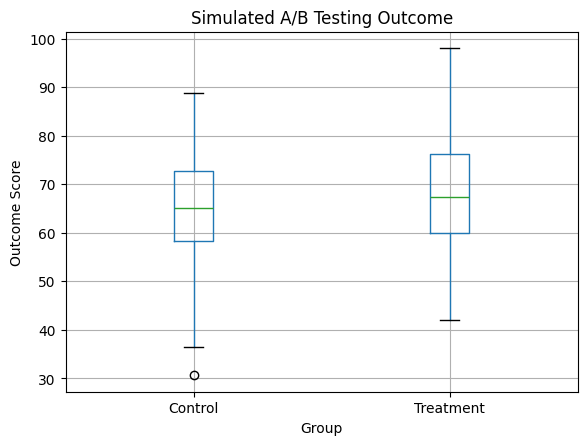

In [189]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

ab_test.boxplot(
    column="outcome_score",
    by="group"
)

plt.title("Simulated A/B Testing Outcome")
plt.suptitle("")
plt.xlabel("Group")
plt.ylabel("Outcome Score")
plt.show()


### Insight

**Evidence:**

Visualisasi boxplot digunakan untuk membandingkan distribusi `outcome_score`
antara kelompok Control dan Treatment pada simulasi A/B Testing.

Berdasarkan hasil perbandingan sebelumnya, rata-rata `outcome_score` pada
kelompok Control adalah **65,07**, sedangkan pada kelompok Treatment sebesar
**67,74**, dengan selisih rata-rata **2,66 poin**.

**Trend Analysis:**

Boxplot digunakan untuk melihat posisi tengah, penyebaran, dan variasi outcome
pada kedua kelompok secara visual. Perbedaan rata-rata sebesar **2,66 poin**
menunjukkan adanya pergeseran nilai outcome antara kedua kelompok pada data
simulasi.

**Actionable Insight:**

Visualisasi melengkapi analisis A/B Testing yang telah dilakukan melalui
perbandingan rata-rata, independent t-test, dan Cohen's d.

Namun, seluruh pola yang terlihat pada grafik berasal dari **data sintetis**
dan simulated treatment effect. Oleh karena itu, visualisasi ini hanya
digunakan untuk mendemonstrasikan metode evaluasi A/B Testing dan bukan untuk
menyimpulkan efektivitas aktual rekomendasi EduPulse.

### Insight

**Evidence:**

Pada simulasi A/B Testing, kelompok Control memiliki rata-rata outcome sebesar
**65,07**, sedangkan kelompok Treatment sebesar **67,74**, dengan selisih
rata-rata **2,66 poin**.

Independent t-test menghasilkan **T-statistic 2,3331** dan **p-value
0,0201** pada tingkat signifikansi **α = 0,05**. Cohen's d yang diperoleh
adalah **0,2333**.

**Trend Analysis:**

Pada data simulasi, rata-rata outcome kelompok Treatment lebih tinggi
dibandingkan Control sebesar **2,66 poin**. Hasil statistical test juga
menunjukkan bahwa perbedaan tersebut terdeteksi secara statistik pada tingkat
signifikansi **5%**.

Namun, outcome dibentuk menggunakan **noise sintetis** dan kelompok Treatment
diberikan **simulated treatment effect sebesar 3 poin**.

**Actionable Insight:**

Analisis ini mendemonstrasikan rangkaian evaluasi A/B Testing yang dapat
digunakan pada EduPulse, yaitu perbandingan rata-rata, independent t-test, dan
effect size.

Hasil simulasi **tidak dapat digunakan sebagai bukti efektivitas aktual
rekomendasi EduPulse**. Evaluasi aktual memerlukan pengguna nyata, random
assignment, intervensi rekomendasi yang benar-benar diberikan, dan pengukuran
outcome setelah periode intervensi.

# **14. Conclusion & Recommendation**

- **Conclusion pertanyaan 1:**

**Evidence:**  

Hasil Exploratory Data Analysis menunjukkan adanya hubungan positif antara
kehadiran, hasil internal test, assignment, dan kebiasaan belajar dengan nilai
`Final Exam`.

Korelasi `Attendance` dengan `Final Exam` sebesar **0,7256**, `Internal Test 1`
sebesar **0,6892**, `Internal Test 2` sebesar **0,6910**, `Assignment` sebesar
**0,6694**, dan `Daily Study Hours` sebesar **0,4129**.

**Trend Analysis:**  

Di antara fitur individual, `Attendance` memiliki korelasi paling tinggi dengan
`Final Exam`, yaitu **0,7256**, diikuti `Internal Test 2` sebesar **0,6910**,
`Internal Test 1` sebesar **0,6892**, `Assignment` sebesar **0,6694**, dan
`Daily Study Hours` sebesar **0,4129**.

Profiling berdasarkan kelompok performa juga menunjukkan pola yang konsisten.
Rata-rata `Attendance` meningkat dari **78,08%** pada kelompok Low Performance
menjadi **92,28%** pada kelompok High Performance. Rata-rata `Daily Study Hours`
meningkat dari **2,53 jam** menjadi **3,14 jam per hari**.

Pada kelompok yang sama, rata-rata `Final Exam` meningkat dari **50,88** pada
Low Performance menjadi **79,55** pada High Performance.

**Actionable Insight:**  

Attendance, hasil internal test, assignment, dan daily study hours dapat
digunakan sebagai informasi pendukung untuk memahami kondisi akademik siswa
dan mendukung proses early warning.

Hasil ini bersifat **deskriptif** dan menunjukkan hubungan antarvariabel,
bukan hubungan sebab-akibat.


- **Conclusion pertanyaan 2:**

**Evidence:**  

Hasil analisis korelasi menunjukkan bahwa di antara fitur individual,
`Attendance` memiliki korelasi sebesar **0,7256** dengan `Final Exam`,
`Internal Test 2` sebesar **0,6910**, `Internal Test 1` sebesar **0,6892**,
`Assignment` sebesar **0,6694**, dan `Daily Study Hours` sebesar **0,4129**.

Pada tahap feature engineering, `academic_average` memiliki korelasi sebesar
**0,8584**, sedangkan `assessment_average` memiliki korelasi sebesar **0,8683**
dengan `Final Exam`.

**Trend Analysis:**  

Fitur agregat menunjukkan korelasi yang lebih tinggi dengan `Final Exam`
dibandingkan masing-masing fitur individual. `Assessment_average` memiliki
korelasi tertinggi sebesar **0,8683**, diikuti `academic_average` sebesar
**0,8584**.

Meskipun demikian, fitur agregat tersebut dibentuk dari indikator yang sudah
digunakan pada fitur utama. Oleh karena itu, penambahannya diuji sebagai bagian
dari eksperimen feature engineering dan tidak otomatis menjadi konfigurasi
fitur final.

**Actionable Insight:**  

Lima fitur utama yang digunakan pada model final adalah `attendance`,
`internal_test_1_pct`, `internal_test_2_pct`, `assignment_pct`, dan
`daily_study_hours`.

`Academic_average` dan `assessment_average` tetap dapat dipertimbangkan untuk
eksperimen pengembangan berikutnya karena memiliki korelasi yang kuat dengan
`Final Exam`, tetapi dampaknya terhadap performa model harus dibuktikan
melalui evaluasi pemodelan.


- **Conclusion pertanyaan 3:**

**Evidence:**  

Hasil **5-Fold Cross Validation** menunjukkan bahwa Linear Regression
menghasilkan **MAE 3,606**, **RMSE 4,577**, dan **R² 0,837**.

Pada evaluasi yang sama, Random Forest menghasilkan **RMSE 5,137**,
sedangkan Gradient Boosting menghasilkan **RMSE 4,902**.

Setelah hyperparameter tuning, Random Forest menghasilkan **CV RMSE 4,988**,
Gradient Boosting **4,833**, dan Decision Tree **5,691**.

Pada evaluasi akhir menggunakan **400 data testing**, Linear Regression
menghasilkan **MAE 3,675**, **RMSE 4,618**, dan **R² 0,830**.

Untuk Early Warning classification menggunakan threshold **70**, model
menghasilkan **accuracy 89%**. Pada kategori `At Risk`, model memperoleh
**precision 89%**, **recall 94%**, dan **F1-score 91%**.

**Trend Analysis:**  

Hasil 5-Fold Cross Validation menunjukkan bahwa Linear Regression memiliki
**RMSE 4,577**, sedangkan Gradient Boosting Tuned **4,833**, Random Forest
Tuned **4,988**, dan Decision Tree Tuned **5,691**.

Pada evaluasi Early Warning, dari **261 siswa yang secara aktual termasuk
At Risk**, sebanyak **245 siswa** berhasil teridentifikasi sebagai At Risk,
sedangkan **16 siswa** tidak terdeteksi.

**Actionable Insight:**  

Linear Regression digunakan sebagai model final untuk memprediksi nilai
`Final Exam`, kemudian hasil prediksi diterjemahkan menjadi kategori risiko
untuk mendukung sistem Early Warning EduPulse.

Threshold operasional yang digunakan adalah:

- **High Risk:** predicted final < 70
- **Medium Risk:** predicted final 70 hingga < 80
- **Low Risk:** predicted final ≥ 80

Untuk deployment, model dikemas dalam `edupulse_model_final.joblib` dan
digunakan bersama fungsi `predict.py` tanpa mengubah interface prediksi yang
telah digunakan pada aplikasi.


### **Rekomendasi Action Item**

- **Meningkatkan monitoring siswa berisiko:**  

  Menggunakan `Predicted Final Exam`, `Risk Level`, dan indikator akademik
  sebagai informasi pendukung untuk membantu sekolah mengidentifikasi siswa
  yang membutuhkan pemantauan lebih lanjut.

- **Mengembangkan fitur rekomendasi yang lebih spesifik:**  

  Mengembangkan rekomendasi berdasarkan kondisi siswa, seperti attendance,
  hasil internal test, assignment, dan daily study hours, sehingga tindak
  lanjut dapat disesuaikan dengan profil akademik siswa.

- **Menguji feature engineering lebih lanjut:**  

  Menguji kembali `academic_average` dan `assessment_average` pada eksperimen
  berikutnya untuk mengetahui apakah fitur agregat tersebut memberikan
  peningkatan performa model yang konsisten.

- **Melakukan evaluasi model secara berkala:**  

  Menggunakan data siswa terbaru untuk mengevaluasi kembali MAE, RMSE, R²,
  performa Early Warning, serta threshold risiko agar model tetap sesuai
  dengan kebutuhan sistem.

- **Mengembangkan validasi menggunakan data aktual:**  

  Melakukan validasi menggunakan data operasional dari institusi pendidikan
  untuk mengetahui performa model pada kondisi penggunaan sebenarnya.

- **Melakukan evaluasi intervensi secara aktual:**  

  A/B Testing dapat dilakukan pada pengguna nyata dengan random assignment,
  intervensi rekomendasi yang benar-benar diberikan, dan pengukuran outcome
  setelah periode intervensi. Simulasi A/B Testing pada notebook ini hanya
  digunakan untuk mendemonstrasikan metodologi dan bukan sebagai bukti
  efektivitas aktual EduPulse.

## **Catatan Implementasi**

Model final yang dipilih adalah **Linear Regression** berdasarkan performa 5-Fold Cross Validation. Random Forest, Gradient Boosting, dan Decision Tree tetap digunakan sebagai model pembanding dan melalui proses hyperparameter tuning.

Perlu dibedakan bahwa **89% merupakan accuracy evaluasi Early Warning classification**, sedangkan performa regresi dilaporkan menggunakan MAE, RMSE, dan R².